# FAO Food Supply Shortage Predictor  
## Notebook 2: Building the Africa-First Analytical Panel

### Purpose

This notebook transforms the validated Stage 1 long-format datasets into an analytical panel with one row for each country, commodity and year.

The workflow will:

1. Load and validate the Stage 1 datasets.
2. Confirm commodity, element and unit identities.
3. Use Nigeria and rice as a controlled pivot test.
4. Pivot the selected FAOSTAT elements into analytical columns.
5. Merge population using M49 code and year.
6. investigate missing values, structural zeros and quality flags.
7. Validate and save the completed analytical panel.

No shortage target or predictive model will be created until the resulting panel has been inspected and understood.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

PROJECT_ROOT = Path(
    "/Users/adewale/Documents/food_security_predictor"
)

AFRICA_FIRST_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "africa_first"
)

SELECTED_DATA_PATH = (
    AFRICA_FIRST_DIR
    / "africa_selected_commodities_long_2010_2023.parquet"
)

POPULATION_DATA_PATH = (
    AFRICA_FIRST_DIR
    / "africa_population_2010_2023.parquet"
)

COMMODITY_METADATA_PATH = (
    AFRICA_FIRST_DIR
    / "selected_commodity_metadata.csv"
)

CANDIDATE_EVIDENCE_PATH = (
    AFRICA_FIRST_DIR
    / "candidate_selection_evidence.csv"
)

COUNTRY_SCOPE_PATH = (
    AFRICA_FIRST_DIR
    / "africa_country_scope.csv"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "02_analytical_panel"
)

PANEL_OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "africa_first"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Confirm that every required Stage 1 file exists
# ---------------------------------------------------------

required_paths = {
    "Selected commodity data": SELECTED_DATA_PATH,
    "Population data": POPULATION_DATA_PATH,
    "Commodity metadata": COMMODITY_METADATA_PATH,
    "Candidate evidence": CANDIDATE_EVIDENCE_PATH,
    "Country scope": COUNTRY_SCOPE_PATH,
}

file_check = pd.DataFrame(
    [
        {
            "File": label,
            "Path": str(path),
            "Exists": path.exists(),
            "Size MB": (
                path.stat().st_size / (1024 ** 2)
                if path.exists()
                else np.nan
            ),
        }
        for label, path in required_paths.items()
    ]
)

print("Stage 1 input files:\n")
display(file_check)

missing_files = file_check.loc[
    ~file_check["Exists"], "File"
].tolist()

assert not missing_files, (
    f"Required files were not found: {missing_files}"
)

# ---------------------------------------------------------
# Load the validated Stage 1 datasets
# ---------------------------------------------------------

selected_long = pd.read_parquet(SELECTED_DATA_PATH)
population_long = pd.read_parquet(POPULATION_DATA_PATH)

commodity_metadata = pd.read_csv(COMMODITY_METADATA_PATH)
candidate_evidence = pd.read_csv(CANDIDATE_EVIDENCE_PATH)
country_scope = pd.read_csv(COUNTRY_SCOPE_PATH)

print("All Stage 1 files loaded successfully.")

Stage 1 input files:



,File,Path,Exists,Size MB
0,Selected commodity data,/Users/adewale/Documents/food_security_predict...,True,0.24
1,Population data,/Users/adewale/Documents/food_security_predict...,True,0.02
2,Commodity metadata,/Users/adewale/Documents/food_security_predict...,True,0.00
3,Candidate evidence,/Users/adewale/Documents/food_security_predict...,True,0.00
4,Country scope,/Users/adewale/Documents/food_security_predict...,True,0.00


All Stage 1 files loaded successfully.


In [3]:
dataset_summary = pd.DataFrame(
    [
        {
            "Dataset": "Selected commodity long data",
            "Rows": len(selected_long),
            "Columns": selected_long.shape[1],
        },
        {
            "Dataset": "Population long data",
            "Rows": len(population_long),
            "Columns": population_long.shape[1],
        },
        {
            "Dataset": "Selected commodity metadata",
            "Rows": len(commodity_metadata),
            "Columns": commodity_metadata.shape[1],
        },
        {
            "Dataset": "Candidate selection evidence",
            "Rows": len(candidate_evidence),
            "Columns": candidate_evidence.shape[1],
        },
        {
            "Dataset": "African country scope",
            "Rows": len(country_scope),
            "Columns": country_scope.shape[1],
        },
    ]
)

print("Loaded dataset summary:\n")
display(dataset_summary)

print("\nSelected commodity data columns:\n")
for number, column in enumerate(selected_long.columns, start=1):
    print(f"{number}. {column}")

print("\nPopulation data columns:\n")
for number, column in enumerate(population_long.columns, start=1):
    print(f"{number}. {column}")

print("\nFirst five selected commodity rows:\n")
display(selected_long.head())

print("\nFirst five population rows:\n")
display(population_long.head())

Loaded dataset summary:



,Dataset,Rows,Columns
0,Selected commodity long data,77994,13
1,Population long data,602,9
2,Selected commodity metadata,8,5
3,Candidate selection evidence,14,17
4,African country scope,55,10



Selected commodity data columns:

1. Area Code
2. Area Code (M49)
3. M49 Code
4. Area
5. Item Code
6. Item Code (FBS)
7. Item
8. Element Code
9. Element
10. Unit
11. Year
12. Value
13. Flag

Population data columns:

1. Area Code
2. Area Code (M49)
3. M49 Code
4. Area
5. Year
6. Population 1000
7. Population unit
8. Population flag
9. Population

First five selected commodity rows:



,Area Code,Area Code (M49),M49 Code,Area,Item Code,Item Code (FBS),Item,Element Code,Element,Unit,Year,Value,Flag
0,4,'012,012,Algeria,2511,'S2511,Wheat and products,645,Food supply quantity (kg/capita/yr),kg/cap,2010,180.60,E
1,4,'012,012,Algeria,2511,'S2511,Wheat and products,645,Food supply quantity (kg/capita/yr),kg/cap,2011,176.75,E
2,4,'012,012,Algeria,2511,'S2511,Wheat and products,645,Food supply quantity (kg/capita/yr),kg/cap,2012,180.26,E
3,4,'012,012,Algeria,2511,'S2511,Wheat and products,645,Food supply quantity (kg/capita/yr),kg/cap,2013,174.50,E
4,4,'012,012,Algeria,2511,'S2511,Wheat and products,645,Food supply quantity (kg/capita/yr),kg/cap,2014,171.92,E



First five population rows:



,Area Code,Area Code (M49),M49 Code,Area,Year,Population 1000,Population unit,Population flag,Population
0,4,'012,012,Algeria,2010,"36,188.24",1000 No,X,"36,188,240.00"
1,4,'012,012,Algeria,2011,"36,903.38",1000 No,X,"36,903,380.00"
2,4,'012,012,Algeria,2012,"37,646.17",1000 No,X,"37,646,170.00"
3,4,'012,012,Algeria,2013,"38,414.17",1000 No,X,"38,414,170.00"
4,4,'012,012,Algeria,2014,"39,205.03",1000 No,X,"39,205,030.00"


In [5]:
# ---------------------------------------------------------
# Validate value and flag alignment
# ---------------------------------------------------------

selected_values_without_flags = (
    selected_long["Value"].notna()
    & selected_long["Flag"].isna()
).sum()

selected_flags_without_values = (
    selected_long["Value"].isna()
    & selected_long["Flag"].notna()
).sum()

duplicate_population_keys = population_long.duplicated(
    subset=["M49 Code", "Year"]
).sum()

# Confirm that the converted population is exactly the
# original FAOSTAT population-in-thousands multiplied by 1,000.
population_conversion_matches = np.allclose(
    population_long["Population"],
    population_long["Population 1000"] * 1_000,
    equal_nan=False,
)

# ---------------------------------------------------------
# Produce the checkpoint summary
# ---------------------------------------------------------

checkpoint_validation = pd.Series(
    {
        "Selected rows": len(selected_long),
        "Population rows": len(population_long),

        "Selected commodities": selected_long[
            "Item Code"
        ].nunique(),

        "Countries in selected data": selected_long[
            "M49 Code"
        ].nunique(),

        "Countries in population data": population_long[
            "M49 Code"
        ].nunique(),

        "Years in selected data": selected_long[
            "Year"
        ].nunique(),

        "Years in population data": population_long[
            "Year"
        ].nunique(),

        "Selected data earliest year": selected_long[
            "Year"
        ].min(),

        "Selected data latest year": selected_long[
            "Year"
        ].max(),

        "Population earliest year": population_long[
            "Year"
        ].min(),

        "Population latest year": population_long[
            "Year"
        ].max(),

        "Missing selected values": selected_long[
            "Value"
        ].isna().sum(),

        "Missing Population 1000 values": population_long[
            "Population 1000"
        ].isna().sum(),

        "Missing converted Population values": population_long[
            "Population"
        ].isna().sum(),

        "Selected values without flags":
            selected_values_without_flags,

        "Selected flags without values":
            selected_flags_without_values,

        "Duplicate population country-year keys":
            duplicate_population_keys,

        "Population conversion matches":
            population_conversion_matches,
    },
    name="Result",
).to_frame()

display(checkpoint_validation)

# ---------------------------------------------------------
# Assertions against the verified Stage 1 results
# ---------------------------------------------------------

assert len(selected_long) == 77_994
assert len(population_long) == 602

assert selected_long["Item Code"].nunique() == 8

assert selected_long["M49 Code"].nunique() == 43
assert population_long["M49 Code"].nunique() == 43

assert selected_long["Year"].nunique() == 14
assert population_long["Year"].nunique() == 14

assert selected_long["Year"].min() == 2010
assert selected_long["Year"].max() == 2023

assert population_long["Year"].min() == 2010
assert population_long["Year"].max() == 2023

assert selected_long["Value"].isna().sum() == 5_999

assert population_long["Population 1000"].isna().sum() == 0
assert population_long["Population"].isna().sum() == 0

assert selected_values_without_flags == 0
assert selected_flags_without_values == 0

assert duplicate_population_keys == 0
assert population_conversion_matches

assert set(population_long["Population unit"].dropna()) == {
    "1000 No"
}

assert set(population_long["Population flag"].dropna()) == {
    "X"
}

print(
    "Notebook 2 has reproduced the validated "
    "Stage 1 checkpoint successfully."
)

,Result
Selected rows,77994
Population rows,602
Selected commodities,8
Countries in selected data,43
Countries in population data,43
Years in selected data,14
Years in population data,14
Selected data earliest year,2010
Selected data latest year,2023
Population earliest year,2010


Notebook 2 has reproduced the validated Stage 1 checkpoint successfully.


## 2. Source Identity, Element and Unit Audit

Before reshaping the selected data, the source identities must be checked again.

This section confirms that:

- each M49 code identifies only one country;
- each item code identifies only one commodity;
- each element code identifies only one element and unit;
- the cleaned and original M49 fields agree;
- each country–commodity–element–year key is unique;
- the selected data still contains exactly twenty element-unit combinations.

These checks protect the analytical panel from silent duplication or incorrect pivoting.

In [6]:
# ---------------------------------------------------------
# Define the intended long-table identity
# ---------------------------------------------------------

long_key = [
    "M49 Code",
    "Item Code",
    "Element Code",
    "Year",
]

duplicate_long_keys = selected_long.duplicated(
    subset=long_key
).sum()

# ---------------------------------------------------------
# Check code-to-label relationships
# ---------------------------------------------------------

country_name_conflicts = (
    selected_long
    .groupby("M49 Code")["Area"]
    .nunique()
    .gt(1)
    .sum()
)

item_label_conflicts = (
    selected_long
    .groupby("Item Code")["Item"]
    .nunique()
    .gt(1)
    .sum()
)

fbs_item_code_conflicts = (
    selected_long
    .groupby("Item Code")["Item Code (FBS)"]
    .nunique()
    .gt(1)
    .sum()
)

element_label_conflicts = (
    selected_long
    .groupby("Element Code")["Element"]
    .nunique()
    .gt(1)
    .sum()
)

element_unit_conflicts = (
    selected_long
    .groupby("Element Code")["Unit"]
    .nunique()
    .gt(1)
    .sum()
)

# ---------------------------------------------------------
# Check the two M49 representations
# ---------------------------------------------------------

selected_original_m49 = (
    selected_long["Area Code (M49)"]
    .astype("string")
    .str.replace("'", "", regex=False)
    .str.zfill(3)
)

selected_clean_m49 = (
    selected_long["M49 Code"]
    .astype("string")
    .str.replace("'", "", regex=False)
    .str.zfill(3)
)

selected_m49_mismatches = (
    selected_original_m49 != selected_clean_m49
).sum()

population_original_m49 = (
    population_long["Area Code (M49)"]
    .astype("string")
    .str.replace("'", "", regex=False)
    .str.zfill(3)
)

population_clean_m49 = (
    population_long["M49 Code"]
    .astype("string")
    .str.replace("'", "", regex=False)
    .str.zfill(3)
)

population_m49_mismatches = (
    population_original_m49 != population_clean_m49
).sum()

# ---------------------------------------------------------
# Summarise the identity checks
# ---------------------------------------------------------

identity_audit = pd.Series(
    {
        "Duplicate long keys": duplicate_long_keys,
        "M49 codes linked to multiple countries":
            country_name_conflicts,
        "Item codes linked to multiple labels":
            item_label_conflicts,
        "Item codes linked to multiple FBS codes":
            fbs_item_code_conflicts,
        "Element codes linked to multiple labels":
            element_label_conflicts,
        "Element codes linked to multiple units":
            element_unit_conflicts,
        "Selected-data M49 mismatches":
            selected_m49_mismatches,
        "Population-data M49 mismatches":
            population_m49_mismatches,
    },
    name="Result",
).to_frame()

print("Identity audit:\n")
display(identity_audit)

# ---------------------------------------------------------
# Build the element-unit audit table
# ---------------------------------------------------------

element_audit = (
    selected_long
    .groupby(
        ["Element Code", "Element", "Unit"],
        dropna=False,
    )
    .agg(
        Source_rows=("Value", "size"),
        Recorded_values=("Value", "count"),
        Countries=("M49 Code", "nunique"),
        Commodities=("Item Code", "nunique"),
        Years=("Year", "nunique"),
        Estimated_values=(
            "Flag",
            lambda values: values.eq("E").sum(),
        ),
        Imputed_values=(
            "Flag",
            lambda values: values.eq("I").sum(),
        ),
    )
    .reset_index()
)

element_audit["Missing values"] = (
    element_audit["Source_rows"]
    - element_audit["Recorded_values"]
)

element_audit["Recorded coverage %"] = (
    element_audit["Recorded_values"]
    .div(element_audit["Source_rows"])
    .mul(100)
    .round(2)
)

element_audit["Estimated % of recorded"] = (
    element_audit["Estimated_values"]
    .div(element_audit["Recorded_values"])
    .mul(100)
    .round(2)
)

element_audit["Imputed % of recorded"] = (
    element_audit["Imputed_values"]
    .div(element_audit["Recorded_values"])
    .mul(100)
    .round(2)
)

element_audit = element_audit.sort_values(
    ["Element Code", "Element"]
).reset_index(drop=True)

print("\nElement and unit audit:\n")

display(
    element_audit[
        [
            "Element Code",
            "Element",
            "Unit",
            "Source_rows",
            "Recorded_values",
            "Missing values",
            "Recorded coverage %",
            "Countries",
            "Commodities",
            "Years",
            "Estimated % of recorded",
            "Imputed % of recorded",
        ]
    ]
)

# ---------------------------------------------------------
# Validate the audit
# ---------------------------------------------------------

assert duplicate_long_keys == 0

assert country_name_conflicts == 0
assert item_label_conflicts == 0
assert fbs_item_code_conflicts == 0
assert element_label_conflicts == 0
assert element_unit_conflicts == 0

assert selected_m49_mismatches == 0
assert population_m49_mismatches == 0

assert len(element_audit) == 20

assert element_audit["Source_rows"].sum() == 77_994
assert element_audit["Recorded_values"].sum() == 71_995
assert element_audit["Missing values"].sum() == 5_999

assert (
    element_audit["Estimated_values"]
    + element_audit["Imputed_values"]
).sum() == 71_995

assert element_audit["Countries"].max() == 43
assert element_audit["Commodities"].max() == 8
assert element_audit["Years"].eq(14).all()

print(
    "\nIdentity, element and unit audit "
    "completed successfully."
)

Identity audit:



,Result
Duplicate long keys,0
M49 codes linked to multiple countries,0
Item codes linked to multiple labels,0
Item codes linked to multiple FBS codes,0
Element codes linked to multiple labels,0
Element codes linked to multiple units,0
Selected-data M49 mismatches,0
Population-data M49 mismatches,0



Element and unit audit:



,Element Code,Element,Unit,Source_rows,Recorded_values,Missing values,Recorded coverage %,Countries,Commodities,Years,Estimated % of recorded,Imputed % of recorded
0,645,Food supply quantity (kg/capita/yr),kg/cap,4536,4309,227,95.00,43,8,14,100.00,0.00
1,661,Food supply (kcal),million Kcal,4536,4311,225,95.04,43,8,14,0.00,100.00
2,664,Food supply (kcal/capita/day),kcal/cap/d,4536,4311,225,95.04,43,8,14,100.00,0.00
3,671,Protein supply quantity (t),t,4536,4311,225,95.04,43,8,14,0.00,100.00
4,674,Protein supply quantity (g/capita/day),g/cap/d,4536,4311,225,95.04,43,8,14,100.00,0.00
5,681,Fat supply quantity (t),t,4536,4311,225,95.04,43,8,14,0.00,100.00
6,684,Fat supply quantity (g/capita/day),g/cap/d,4536,4311,225,95.04,43,8,14,100.00,0.00
7,5072,Stock Variation,1000 t,4074,3987,87,97.86,43,8,14,0.00,100.00
8,5123,Losses,1000 t,3584,3561,23,99.36,43,8,14,0.00,100.00
9,5131,Processing,1000 t,2716,1793,923,66.02,37,7,14,0.00,100.00



Identity, element and unit audit completed successfully.


## 3. Controlled Pivot Test: Nigeria and Rice

Before reshaping all 43 countries and eight commodities, the pivot logic will be tested using Nigeria and rice.

This controlled case will confirm that:

- element codes are converted into clear analytical column names;
- one row is created for each year;
- values and quality flags remain correctly aligned;
- missing values are preserved rather than replaced with zero;
- no rows are multiplied or lost during the pivot.

The test uses Nigeria's M49 code 566 and the FAOSTAT rice item code 2807.

In [7]:
# ---------------------------------------------------------
# Define clear analytical names for all 20 FAOSTAT elements
# ---------------------------------------------------------

ELEMENT_COLUMN_MAP = {
    645: "food_supply_quantity_kg_cap_yr",
    661: "food_supply_million_kcal",
    664: "food_supply_kcal_cap_day",
    671: "protein_supply_t",
    674: "protein_supply_g_cap_day",
    681: "fat_supply_t",
    684: "fat_supply_g_cap_day",
    5072: "stock_variation_1000t",
    5123: "losses_1000t",
    5131: "processing_1000t",
    5142: "food_1000t",
    5154: "other_uses_non_food_1000t",
    5170: "residuals_1000t",
    5171: "tourist_consumption_1000t",
    5301: "domestic_supply_1000t",
    5511: "production_1000t",
    5521: "feed_1000t",
    5527: "seed_1000t",
    5611: "import_quantity_1000t",
    5911: "export_quantity_1000t",
}

element_dictionary = (
    selected_long[
        [
            "Element Code",
            "Element",
            "Unit",
        ]
    ]
    .drop_duplicates()
    .copy()
)

element_dictionary["Panel column"] = (
    element_dictionary["Element Code"]
    .map(ELEMENT_COLUMN_MAP)
)

element_dictionary = element_dictionary.sort_values(
    "Element Code"
).reset_index(drop=True)

print("Analytical element dictionary:\n")
display(element_dictionary)

unmapped_elements = element_dictionary.loc[
    element_dictionary["Panel column"].isna(),
    [
        "Element Code",
        "Element",
        "Unit",
    ],
]

duplicate_panel_names = (
    element_dictionary["Panel column"]
    .dropna()
    .duplicated()
    .sum()
)

assert unmapped_elements.empty, (
    "Some elements do not have analytical column names:\n"
    f"{unmapped_elements}"
)

assert duplicate_panel_names == 0
assert len(ELEMENT_COLUMN_MAP) == 20
assert len(element_dictionary) == 20

print(
    "All 20 element-unit identities have unique "
    "analytical column names."
)

Analytical element dictionary:



,Element Code,Element,Unit,Panel column
0,645,Food supply quantity (kg/capita/yr),kg/cap,food_supply_quantity_kg_cap_yr
1,661,Food supply (kcal),million Kcal,food_supply_million_kcal
2,664,Food supply (kcal/capita/day),kcal/cap/d,food_supply_kcal_cap_day
3,671,Protein supply quantity (t),t,protein_supply_t
4,674,Protein supply quantity (g/capita/day),g/cap/d,protein_supply_g_cap_day
5,681,Fat supply quantity (t),t,fat_supply_t
6,684,Fat supply quantity (g/capita/day),g/cap/d,fat_supply_g_cap_day
7,5072,Stock Variation,1000 t,stock_variation_1000t
8,5123,Losses,1000 t,losses_1000t
9,5131,Processing,1000 t,processing_1000t


All 20 element-unit identities have unique analytical column names.


In [8]:
# ---------------------------------------------------------
# Use normalised M49 text for a reliable country filter
# ---------------------------------------------------------

normalised_selected_m49 = (
    selected_long["M49 Code"]
    .astype("string")
    .str.replace("'", "", regex=False)
    .str.zfill(3)
)

nigeria_rice_source = selected_long.loc[
    normalised_selected_m49.eq("566")
    & selected_long["Item Code"].eq(2807)
].copy()

nigeria_rice_source["Panel column"] = (
    nigeria_rice_source["Element Code"]
    .map(ELEMENT_COLUMN_MAP)
)

# ---------------------------------------------------------
# Summarise the controlled source subset
# ---------------------------------------------------------

nigeria_rice_source_summary = pd.Series(
    {
        "Source rows": len(nigeria_rice_source),
        "Countries": nigeria_rice_source[
            "M49 Code"
        ].nunique(),
        "Country": ", ".join(
            nigeria_rice_source["Area"]
            .dropna()
            .unique()
        ),
        "Commodities": nigeria_rice_source[
            "Item Code"
        ].nunique(),
        "Commodity": ", ".join(
            nigeria_rice_source["Item"]
            .dropna()
            .unique()
        ),
        "Elements represented": nigeria_rice_source[
            "Element Code"
        ].nunique(),
        "Years represented": nigeria_rice_source[
            "Year"
        ].nunique(),
        "Earliest year": nigeria_rice_source[
            "Year"
        ].min(),
        "Latest year": nigeria_rice_source[
            "Year"
        ].max(),
        "Recorded values": nigeria_rice_source[
            "Value"
        ].notna()
        .sum(),
        "Missing values": nigeria_rice_source[
            "Value"
        ].isna()
        .sum(),
        "Duplicate source keys":
            nigeria_rice_source.duplicated(
                subset=[
                    "M49 Code",
                    "Item Code",
                    "Element Code",
                    "Year",
                ]
            ).sum(),
    },
    name="Result",
).to_frame()

print("Nigeria-rice source summary:\n")
display(nigeria_rice_source_summary)

# ---------------------------------------------------------
# Coverage by element for Nigeria and rice
# ---------------------------------------------------------

nigeria_rice_element_coverage = (
    nigeria_rice_source
    .groupby(
        [
            "Element Code",
            "Element",
            "Unit",
            "Panel column",
        ],
        dropna=False,
    )
    .agg(
        Source_rows=("Value", "size"),
        Recorded_values=("Value", "count"),
        First_year=("Year", "min"),
        Last_year=("Year", "max"),
        Estimated_values=(
            "Flag",
            lambda values: values.eq("E").sum(),
        ),
        Imputed_values=(
            "Flag",
            lambda values: values.eq("I").sum(),
        ),
    )
    .reset_index()
)

nigeria_rice_element_coverage["Missing values"] = (
    nigeria_rice_element_coverage["Source_rows"]
    - nigeria_rice_element_coverage["Recorded_values"]
)

nigeria_rice_element_coverage["Coverage %"] = (
    nigeria_rice_element_coverage["Recorded_values"]
    .div(
        nigeria_rice_element_coverage["Source_rows"]
    )
    .mul(100)
    .round(2)
)

nigeria_rice_element_coverage = (
    nigeria_rice_element_coverage
    .sort_values("Element Code")
    .reset_index(drop=True)
)

print("\nNigeria-rice element coverage:\n")
display(nigeria_rice_element_coverage)

assert not nigeria_rice_source.empty
assert nigeria_rice_source["M49 Code"].nunique() == 1
assert nigeria_rice_source["Item Code"].nunique() == 1
assert nigeria_rice_source["Year"].nunique() == 14
assert nigeria_rice_source["Year"].min() == 2010
assert nigeria_rice_source["Year"].max() == 2023

assert (
    nigeria_rice_source_summary.loc[
        "Duplicate source keys",
        "Result",
    ]
    == 0
)

assert nigeria_rice_source["Panel column"].notna().all()

print(
    "\nNigeria-rice source records validated successfully."
)

Nigeria-rice source summary:



,Result
Source rows,252
Countries,1
Country,Nigeria
Commodities,1
Commodity,Rice and products
Elements represented,18
Years represented,14
Earliest year,2010
Latest year,2023
Recorded values,242



Nigeria-rice element coverage:



,Element Code,Element,Unit,Panel column,Source_rows,Recorded_values,First_year,Last_year,Estimated_values,Imputed_values,Missing values,Coverage %
0,645,Food supply quantity (kg/capita/yr),kg/cap,food_supply_quantity_kg_cap_yr,14,14,2010,2023,14,0,0,100.00
1,661,Food supply (kcal),million Kcal,food_supply_million_kcal,14,14,2010,2023,0,14,0,100.00
2,664,Food supply (kcal/capita/day),kcal/cap/d,food_supply_kcal_cap_day,14,14,2010,2023,14,0,0,100.00
3,671,Protein supply quantity (t),t,protein_supply_t,14,14,2010,2023,0,14,0,100.00
4,674,Protein supply quantity (g/capita/day),g/cap/d,protein_supply_g_cap_day,14,14,2010,2023,14,0,0,100.00
5,681,Fat supply quantity (t),t,fat_supply_t,14,14,2010,2023,0,14,0,100.00
6,684,Fat supply quantity (g/capita/day),g/cap/d,fat_supply_g_cap_day,14,14,2010,2023,14,0,0,100.00
7,5072,Stock Variation,1000 t,stock_variation_1000t,14,14,2010,2023,0,14,0,100.00
8,5123,Losses,1000 t,losses_1000t,14,14,2010,2023,0,14,0,100.00
9,5131,Processing,1000 t,processing_1000t,14,4,2010,2023,0,4,10,28.57



Nigeria-rice source records validated successfully.


In [9]:
# ---------------------------------------------------------
# Columns that uniquely identify a panel row
# ---------------------------------------------------------

panel_index = [
    "Area Code",
    "Area Code (M49)",
    "M49 Code",
    "Area",
    "Item Code",
    "Item Code (FBS)",
    "Item",
    "Year",
]

panel_value_columns = list(ELEMENT_COLUMN_MAP.values())

# ---------------------------------------------------------
# Pivot numerical values
# ---------------------------------------------------------

nigeria_rice_values = (
    nigeria_rice_source
    .pivot(
        index=panel_index,
        columns="Panel column",
        values="Value",
    )
    .reindex(columns=panel_value_columns)
    .reset_index()
)

# ---------------------------------------------------------
# Pivot the matching quality flags
# ---------------------------------------------------------

nigeria_rice_flags = (
    nigeria_rice_source
    .pivot(
        index=panel_index,
        columns="Panel column",
        values="Flag",
    )
    .reindex(columns=panel_value_columns)
    .rename(
        columns={
            column: f"{column}_flag"
            for column in panel_value_columns
        }
    )
    .reset_index()
)

# ---------------------------------------------------------
# Merge values and flags back together
# ---------------------------------------------------------

nigeria_rice_panel = nigeria_rice_values.merge(
    nigeria_rice_flags,
    on=panel_index,
    how="outer",
    validate="one_to_one",
)

nigeria_rice_panel = nigeria_rice_panel.sort_values(
    "Year"
).reset_index(drop=True)

# ---------------------------------------------------------
# Validate the controlled panel
# ---------------------------------------------------------

nigeria_rice_panel_summary = pd.Series(
    {
        "Panel rows": len(nigeria_rice_panel),
        "Expected rows": 14,
        "Unique years": nigeria_rice_panel[
            "Year"
        ].nunique(),
        "Earliest year": nigeria_rice_panel[
            "Year"
        ].min(),
        "Latest year": nigeria_rice_panel[
            "Year"
        ].max(),
        "Value columns": len(panel_value_columns),
        "Flag columns": len(
            [
                column
                for column in nigeria_rice_panel.columns
                if column.endswith("_flag")
            ]
        ),
        "Missing analytical values":
            nigeria_rice_panel[
                panel_value_columns
            ]
            .isna()
            .sum()
            .sum(),
        "Duplicate panel years":
            nigeria_rice_panel["Year"]
            .duplicated()
            .sum(),
    },
    name="Result",
).to_frame()

print("Nigeria-rice panel summary:\n")
display(nigeria_rice_panel_summary)

assert len(nigeria_rice_panel) == 14
assert nigeria_rice_panel["Year"].nunique() == 14
assert nigeria_rice_panel["Year"].min() == 2010
assert nigeria_rice_panel["Year"].max() == 2023
assert nigeria_rice_panel["Year"].is_unique

assert len(panel_value_columns) == 20

assert sum(
    column.endswith("_flag")
    for column in nigeria_rice_panel.columns
) == 20

# ---------------------------------------------------------
# Display a readable selection of the panel
# ---------------------------------------------------------

nigeria_rice_core_view = nigeria_rice_panel[
    [
        "Area",
        "Item",
        "Year",
        "production_1000t",
        "import_quantity_1000t",
        "export_quantity_1000t",
        "stock_variation_1000t",
        "domestic_supply_1000t",
        "food_1000t",
        "food_supply_quantity_kg_cap_yr",
        "food_supply_kcal_cap_day",
    ]
]

print("\nNigeria-rice analytical values:\n")
display(nigeria_rice_core_view)

nigeria_rice_core_flags = nigeria_rice_panel[
    [
        "Year",
        "production_1000t_flag",
        "import_quantity_1000t_flag",
        "export_quantity_1000t_flag",
        "stock_variation_1000t_flag",
        "domestic_supply_1000t_flag",
        "food_1000t_flag",
        "food_supply_quantity_kg_cap_yr_flag",
        "food_supply_kcal_cap_day_flag",
    ]
]

print("\nMatching quality flags:\n")
display(nigeria_rice_core_flags)

print(
    "\nNigeria-rice controlled pivot completed successfully."
)

Nigeria-rice panel summary:



,Result
Panel rows,14
Expected rows,14
Unique years,14
Earliest year,2010
Latest year,2023
Value columns,20
Flag columns,20
Missing analytical values,38
Duplicate panel years,0



Nigeria-rice analytical values:



Panel column,Area,Item,Year,production_1000t,import_quantity_1000t,export_quantity_1000t,stock_variation_1000t,domestic_supply_1000t,food_1000t,food_supply_quantity_kg_cap_yr,food_supply_kcal_cap_day
0,Nigeria,Rice and products,2010,"4,473.00","2,833.00",0.00,0.00,"7,306.00","7,075.00",42.46,277.69
1,Nigeria,Rice and products,2011,"4,613.00","3,290.00",0.00,0.00,"7,902.00","7,665.00",44.73,292.07
2,Nigeria,Rice and products,2012,"5,433.00","2,923.00",0.00,0.00,"8,356.00","8,077.00",45.84,300.34
3,Nigeria,Rice and products,2013,"4,823.00","3,291.00",0.00,0.00,"8,115.00","7,867.00",43.45,283.97
4,Nigeria,Rice and products,2014,"6,003.00","2,469.00",1.00,"1,463.00","7,008.00","6,699.00",36.04,236.64
5,Nigeria,Rice and products,2015,"6,256.00","1,297.00",1.00,43.00,"7,510.00","7,190.00",37.71,249.24
6,Nigeria,Rice and products,2016,"7,564.00",210.00,0.00,352.00,"7,421.00","7,038.00",36.01,237.84
7,Nigeria,Rice and products,2017,"7,826.00",170.00,4.00,492.00,"7,500.00","7,107.00",35.49,235.70
8,Nigeria,Rice and products,2018,"8,403.00",93.00,6.00,844.00,"7,645.00","7,225.00",35.25,234.49
9,Nigeria,Rice and products,2019,"8,435.00","1,277.00",0.00,"1,124.00","8,588.00","8,143.00",38.87,257.15



Matching quality flags:



Panel column,Year,production_1000t_flag,import_quantity_1000t_flag,export_quantity_1000t_flag,stock_variation_1000t_flag,domestic_supply_1000t_flag,food_1000t_flag,food_supply_quantity_kg_cap_yr_flag,food_supply_kcal_cap_day_flag
0,2010,I,I,I,I,I,I,E,E
1,2011,I,I,I,I,I,I,E,E
2,2012,I,I,I,I,I,I,E,E
3,2013,I,I,I,I,I,I,E,E
4,2014,I,I,I,I,I,I,E,E
5,2015,I,I,I,I,I,I,E,E
6,2016,I,I,I,I,I,I,E,E
7,2017,I,I,I,I,I,I,E,E
8,2018,I,I,I,I,I,I,E,E
9,2019,I,I,I,I,I,I,E,E



Nigeria-rice controlled pivot completed successfully.


## 4. Constructing the Complete Africa-First Panel

The source long table does not contain every possible element for every country–commodity–year combination. A direct pivot would therefore hide combinations that were completely absent from the source.

To avoid this, the complete analytical grid is created first:

- 43 countries;
- 8 selected commodities;
- 14 years from 2010 to 2023.

The expected panel contains 4,816 rows.

Values, flags and source-presence indicators are then attached to this complete grid. This makes it possible to distinguish:

1. a recorded value;
2. a source row whose value is missing;
3. an element that has no source row for that country–commodity–year;
4. a genuine reported zero.

In [10]:
# ---------------------------------------------------------
# Create controlled country and commodity dimensions
# ---------------------------------------------------------

country_dimension = (
    selected_long[
        [
            "Area Code",
            "Area Code (M49)",
            "M49 Code",
            "Area",
        ]
    ]
    .drop_duplicates()
    .sort_values("M49 Code")
    .reset_index(drop=True)
)

commodity_dimension = (
    selected_long[
        [
            "Item Code",
            "Item Code (FBS)",
            "Item",
        ]
    ]
    .drop_duplicates()
    .sort_values("Item Code")
    .reset_index(drop=True)
)

year_dimension = pd.DataFrame(
    {
        "Year": list(range(2010, 2024))
    }
)

# ---------------------------------------------------------
# Validate the dimensions before crossing them
# ---------------------------------------------------------

assert len(country_dimension) == 43
assert country_dimension["M49 Code"].is_unique
assert country_dimension["Area"].is_unique

assert len(commodity_dimension) == 8
assert commodity_dimension["Item Code"].is_unique
assert commodity_dimension["Item Code (FBS)"].is_unique

assert len(year_dimension) == 14
assert year_dimension["Year"].is_unique

# ---------------------------------------------------------
# Build the complete analytical grid
# ---------------------------------------------------------

complete_panel_grid = (
    country_dimension
    .merge(
        commodity_dimension,
        how="cross",
    )
    .merge(
        year_dimension,
        how="cross",
    )
)

complete_panel_grid = complete_panel_grid[
    panel_index
].sort_values(
    [
        "M49 Code",
        "Item Code",
        "Year",
    ]
).reset_index(drop=True)

expected_panel_rows = 43 * 8 * 14

grid_summary = pd.Series(
    {
        "Countries": country_dimension.shape[0],
        "Commodities": commodity_dimension.shape[0],
        "Years": year_dimension.shape[0],
        "Expected panel rows": expected_panel_rows,
        "Actual panel rows": len(complete_panel_grid),
        "Duplicate panel keys":
            complete_panel_grid.duplicated(
                subset=[
                    "M49 Code",
                    "Item Code",
                    "Year",
                ]
            ).sum(),
    },
    name="Result",
).to_frame()

print("Complete panel-grid summary:\n")
display(grid_summary)

print("\nFirst five grid rows:\n")
display(complete_panel_grid.head())

assert len(complete_panel_grid) == 4_816

assert not complete_panel_grid.duplicated(
    subset=[
        "M49 Code",
        "Item Code",
        "Year",
    ]
).any()

print(
    "\nComplete 43-country, 8-commodity and "
    "14-year grid created successfully."
)

Complete panel-grid summary:



,Result
Countries,43
Commodities,8
Years,14
Expected panel rows,4816
Actual panel rows,4816
Duplicate panel keys,0



First five grid rows:



,Area Code,Area Code (M49),M49 Code,Area,Item Code,Item Code (FBS),Item,Year
0,4,'012,012,Algeria,2511,'S2511,Wheat and products,2010
1,4,'012,012,Algeria,2511,'S2511,Wheat and products,2011
2,4,'012,012,Algeria,2511,'S2511,Wheat and products,2012
3,4,'012,012,Algeria,2511,'S2511,Wheat and products,2013
4,4,'012,012,Algeria,2511,'S2511,Wheat and products,2014



Complete 43-country, 8-commodity and 14-year grid created successfully.


In [11]:
# ---------------------------------------------------------
# Attach analytical element names to the full source table
# ---------------------------------------------------------

selected_panel_source = selected_long.copy()

selected_panel_source["Panel column"] = (
    selected_panel_source["Element Code"]
    .map(ELEMENT_COLUMN_MAP)
)

selected_panel_source["_source_present"] = 1

assert selected_panel_source["Panel column"].notna().all()

# ---------------------------------------------------------
# Pivot numerical values
# ---------------------------------------------------------

observed_values_wide = (
    selected_panel_source
    .pivot(
        index=panel_index,
        columns="Panel column",
        values="Value",
    )
    .reindex(columns=panel_value_columns)
)

observed_values_wide.columns.name = None
observed_values_wide = observed_values_wide.reset_index()

# ---------------------------------------------------------
# Pivot quality flags
# ---------------------------------------------------------

observed_flags_wide = (
    selected_panel_source
    .pivot(
        index=panel_index,
        columns="Panel column",
        values="Flag",
    )
    .reindex(columns=panel_value_columns)
)

observed_flags_wide.columns = [
    f"{column}_flag"
    for column in observed_flags_wide.columns
]

observed_flags_wide.columns.name = None
observed_flags_wide = observed_flags_wide.reset_index()

# ---------------------------------------------------------
# Pivot source-presence indicators
# ---------------------------------------------------------

observed_presence_wide = (
    selected_panel_source
    .pivot(
        index=panel_index,
        columns="Panel column",
        values="_source_present",
    )
    .reindex(columns=panel_value_columns)
    .fillna(0)
    .astype("int8")
)

observed_presence_wide.columns = [
    f"{column}_source_present"
    for column in observed_presence_wide.columns
]

observed_presence_wide.columns.name = None
observed_presence_wide = observed_presence_wide.reset_index()

# ---------------------------------------------------------
# Attach all three layers to the complete grid
# ---------------------------------------------------------

analytical_panel = (
    complete_panel_grid
    .merge(
        observed_values_wide,
        on=panel_index,
        how="left",
        validate="one_to_one",
    )
    .merge(
        observed_flags_wide,
        on=panel_index,
        how="left",
        validate="one_to_one",
    )
    .merge(
        observed_presence_wide,
        on=panel_index,
        how="left",
        validate="one_to_one",
    )
)

presence_columns = [
    f"{column}_source_present"
    for column in panel_value_columns
]

flag_columns = [
    f"{column}_flag"
    for column in panel_value_columns
]

# A grid row with no source records at all will have missing
# presence indicators after the merge. These represent absence
# from the source and are therefore correctly set to zero.
analytical_panel[presence_columns] = (
    analytical_panel[presence_columns]
    .fillna(0)
    .astype("int8")
)

analytical_panel = analytical_panel.sort_values(
    [
        "M49 Code",
        "Item Code",
        "Year",
    ]
).reset_index(drop=True)

print(
    "Values, flags and source-presence indicators "
    "attached successfully."
)

Values, flags and source-presence indicators attached successfully.


In [13]:
# ---------------------------------------------------------
# Remove the hidden pivot column-axis label
# ---------------------------------------------------------

analytical_panel.columns.name = None
nigeria_rice_panel.columns.name = None

# ---------------------------------------------------------
# Recreate the two comparison tables
# ---------------------------------------------------------

full_panel_m49 = (
    analytical_panel["M49 Code"]
    .astype("string")
    .str.replace("'", "", regex=False)
    .str.zfill(3)
)

nigeria_rice_from_full_panel = (
    analytical_panel.loc[
        full_panel_m49.eq("566")
        & analytical_panel["Item Code"].eq(2807),
        [
            "Year",
            *panel_value_columns,
            *flag_columns,
        ],
    ]
    .sort_values("Year")
    .reset_index(drop=True)
    .rename_axis(columns=None)
)

nigeria_rice_expected = (
    nigeria_rice_panel[
        [
            "Year",
            *panel_value_columns,
            *flag_columns,
        ]
    ]
    .sort_values("Year")
    .reset_index(drop=True)
    .rename_axis(columns=None)
)

# ---------------------------------------------------------
# Perform a strict comparison of labels and values
# ---------------------------------------------------------

pd.testing.assert_frame_equal(
    nigeria_rice_from_full_panel,
    nigeria_rice_expected,
    check_dtype=False,
)

print(
    "The complete panel passed all validations."
)

print(
    "Nigeria-rice in the complete panel exactly matches "
    "the controlled pivot."
)

The complete panel passed all validations.
Nigeria-rice in the complete panel exactly matches the controlled pivot.


In [14]:
full_panel_element_records = []

for _, element_row in element_dictionary.iterrows():
    value_column = element_row["Panel column"]
    flag_column = f"{value_column}_flag"
    presence_column = (
        f"{value_column}_source_present"
    )

    source_present = analytical_panel[
        presence_column
    ].eq(1)

    value_recorded = analytical_panel[
        value_column
    ].notna()

    source_rows = int(source_present.sum())
    recorded_values = int(value_recorded.sum())

    source_present_missing = int(
        (
            source_present
            & ~value_recorded
        ).sum()
    )

    absent_source_rows = int(
        (~source_present).sum()
    )

    full_panel_element_records.append(
        {
            "Element Code":
                element_row["Element Code"],
            "Element":
                element_row["Element"],
            "Unit":
                element_row["Unit"],
            "Panel column":
                value_column,
            "Total panel cells":
                len(analytical_panel),
            "Source rows":
                source_rows,
            "Recorded values":
                recorded_values,
            "Source-present missing":
                source_present_missing,
            "Absent source rows":
                absent_source_rows,
            "Source-row availability %":
                round(
                    source_rows
                    / len(analytical_panel)
                    * 100,
                    2,
                ),
            "Recorded within source rows %":
                round(
                    recorded_values
                    / source_rows
                    * 100,
                    2,
                )
                if source_rows
                else np.nan,
            "Overall panel coverage %":
                round(
                    recorded_values
                    / len(analytical_panel)
                    * 100,
                    2,
                ),
        }
    )

full_panel_element_coverage = pd.DataFrame(
    full_panel_element_records
).sort_values(
    "Element Code"
).reset_index(drop=True)

print("True full-panel coverage by element:\n")
display(full_panel_element_coverage)

assert (
    full_panel_element_coverage[
        "Total panel cells"
    ]
    .eq(4_816)
    .all()
)

assert (
    full_panel_element_coverage[
        "Source rows"
    ].sum()
    == 77_994
)

assert (
    full_panel_element_coverage[
        "Recorded values"
    ].sum()
    == 71_995
)

assert (
    full_panel_element_coverage[
        "Source-present missing"
    ].sum()
    == 5_999
)

assert (
    full_panel_element_coverage[
        "Absent source rows"
    ].sum()
    == 18_326
)

print(
    "\nFull-panel element coverage validated successfully."
)

True full-panel coverage by element:



,Element Code,Element,Unit,Panel column,Total panel cells,Source rows,Recorded values,Source-present missing,Absent source rows,Source-row availability %,Recorded within source rows %,Overall panel coverage %
0,645,Food supply quantity (kg/capita/yr),kg/cap,food_supply_quantity_kg_cap_yr,4816,4536,4309,227,280,94.19,95.00,89.47
1,661,Food supply (kcal),million Kcal,food_supply_million_kcal,4816,4536,4311,225,280,94.19,95.04,89.51
2,664,Food supply (kcal/capita/day),kcal/cap/d,food_supply_kcal_cap_day,4816,4536,4311,225,280,94.19,95.04,89.51
3,671,Protein supply quantity (t),t,protein_supply_t,4816,4536,4311,225,280,94.19,95.04,89.51
4,674,Protein supply quantity (g/capita/day),g/cap/d,protein_supply_g_cap_day,4816,4536,4311,225,280,94.19,95.04,89.51
5,681,Fat supply quantity (t),t,fat_supply_t,4816,4536,4311,225,280,94.19,95.04,89.51
6,684,Fat supply quantity (g/capita/day),g/cap/d,fat_supply_g_cap_day,4816,4536,4311,225,280,94.19,95.04,89.51
7,5072,Stock Variation,1000 t,stock_variation_1000t,4816,4074,3987,87,742,84.59,97.86,82.79
8,5123,Losses,1000 t,losses_1000t,4816,3584,3561,23,1232,74.42,99.36,73.94
9,5131,Processing,1000 t,processing_1000t,4816,2716,1793,923,2100,56.40,66.02,37.23



Full-panel element coverage validated successfully.


## 5. Population Merge and Unit Consistency

Population is country-year context rather than a commodity measure. It will therefore be merged into the analytical panel using M49 code and year.

The merge must satisfy a many-to-one relationship:

- each country-year has one population record;
- each population record is repeated across eight commodities;
- no analytical row should be lost or multiplied;
- every panel row should receive a population value.

After merging, population will be used to independently recalculate selected per-capita measures. This will test whether the population merge, units and FAOSTAT measures are internally consistent.

In [15]:
# ---------------------------------------------------------
# Prepare a controlled population merge table
# ---------------------------------------------------------

population_merge_columns = [
    "M49 Code",
    "Year",
    "Population 1000",
    "Population unit",
    "Population flag",
    "Population",
]

population_for_merge = population_long[
    population_merge_columns
].copy()

# Normalise the merge identifier on both sides
population_for_merge["M49 Code"] = (
    population_for_merge["M49 Code"]
    .astype("string")
    .str.replace("'", "", regex=False)
    .str.zfill(3)
)

analytical_panel["M49 Code"] = (
    analytical_panel["M49 Code"]
    .astype("string")
    .str.replace("'", "", regex=False)
    .str.zfill(3)
)

# ---------------------------------------------------------
# Validate the population merge key
# ---------------------------------------------------------

duplicate_population_merge_keys = (
    population_for_merge.duplicated(
        subset=[
            "M49 Code",
            "Year",
        ]
    ).sum()
)

assert duplicate_population_merge_keys == 0
assert len(population_for_merge) == 602

# ---------------------------------------------------------
# Perform a many-to-one merge
# ---------------------------------------------------------

rows_before_population_merge = len(analytical_panel)

analytical_panel_with_population = (
    analytical_panel
    .merge(
        population_for_merge,
        on=[
            "M49 Code",
            "Year",
        ],
        how="left",
        validate="many_to_one",
        indicator="_population_merge",
    )
)

rows_after_population_merge = len(
    analytical_panel_with_population
)

population_matches = (
    analytical_panel_with_population[
        "_population_merge"
    ]
    .eq("both")
    .sum()
)

unmatched_panel_rows = (
    analytical_panel_with_population[
        "_population_merge"
    ]
    .eq("left_only")
    .sum()
)

# ---------------------------------------------------------
# Confirm population repeats correctly across commodities
# ---------------------------------------------------------

rows_per_country_year = (
    analytical_panel_with_population
    .groupby(
        [
            "M49 Code",
            "Year",
        ]
    )
    .size()
)

population_values_per_country_year = (
    analytical_panel_with_population
    .groupby(
        [
            "M49 Code",
            "Year",
        ]
    )["Population"]
    .nunique(dropna=False)
)

population_merge_summary = pd.Series(
    {
        "Rows before population merge":
            rows_before_population_merge,
        "Rows after population merge":
            rows_after_population_merge,
        "Panel columns after merge":
            analytical_panel_with_population.shape[1] - 1,
        "Population country-year records":
            len(population_for_merge),
        "Matched panel rows":
            population_matches,
        "Unmatched panel rows":
            unmatched_panel_rows,
        "Missing Population 1000 values":
            analytical_panel_with_population[
                "Population 1000"
            ].isna().sum(),
        "Missing Population values":
            analytical_panel_with_population[
                "Population"
            ].isna().sum(),
        "Minimum commodity rows per country-year":
            rows_per_country_year.min(),
        "Maximum commodity rows per country-year":
            rows_per_country_year.max(),
        "Country-years with conflicting populations":
            population_values_per_country_year
            .gt(1)
            .sum(),
        "Duplicate final panel keys":
            analytical_panel_with_population
            .duplicated(
                subset=[
                    "M49 Code",
                    "Item Code",
                    "Year",
                ]
            )
            .sum(),
    },
    name="Result",
).to_frame()

print("Population merge summary:\n")
display(population_merge_summary)

# ---------------------------------------------------------
# Validate the completed merge
# ---------------------------------------------------------

assert rows_before_population_merge == 4_816
assert rows_after_population_merge == 4_816

assert population_matches == 4_816
assert unmatched_panel_rows == 0

assert analytical_panel_with_population[
    "Population 1000"
].notna().all()

assert analytical_panel_with_population[
    "Population"
].notna().all()

assert rows_per_country_year.eq(8).all()

assert population_values_per_country_year.eq(1).all()

assert analytical_panel_with_population[
    "Population"
].gt(0).all()

assert set(
    analytical_panel_with_population[
        "Population unit"
    ].dropna()
) == {"1000 No"}

assert set(
    analytical_panel_with_population[
        "Population flag"
    ].dropna()
) == {"X"}

assert np.allclose(
    analytical_panel_with_population[
        "Population"
    ],
    analytical_panel_with_population[
        "Population 1000"
    ] * 1_000,
)

assert not analytical_panel_with_population.duplicated(
    subset=[
        "M49 Code",
        "Item Code",
        "Year",
    ]
).any()

# The merge indicator is no longer needed
analytical_panel_with_population = (
    analytical_panel_with_population
    .drop(columns="_population_merge")
)

print(
    "\nPopulation merged successfully using "
    "a validated many-to-one relationship."
)

Population merge summary:



,Result
Rows before population merge,4816
Rows after population merge,4816
Panel columns after merge,72
Population country-year records,602
Matched panel rows,4816
Unmatched panel rows,0
Missing Population 1000 values,0
Missing Population values,0
Minimum commodity rows per country-year,8
Maximum commodity rows per country-year,8



Population merged successfully using a validated many-to-one relationship.


In [16]:
# ---------------------------------------------------------
# Define internal consistency checks
# ---------------------------------------------------------

consistency_definitions = [
    {
        "Check": "Food quantity",
        "Total column": "food_1000t",
        "Reported per-capita column":
            "food_supply_quantity_kg_cap_yr",
        "Daily measure": False,
        "Comparison unit": "kg/capita/year",
    },
    {
        "Check": "Calorie supply",
        "Total column": "food_supply_million_kcal",
        "Reported per-capita column":
            "food_supply_kcal_cap_day",
        "Daily measure": True,
        "Comparison unit": "kcal/capita/day",
    },
    {
        "Check": "Protein supply",
        "Total column": "protein_supply_t",
        "Reported per-capita column":
            "protein_supply_g_cap_day",
        "Daily measure": True,
        "Comparison unit": "g/capita/day",
    },
    {
        "Check": "Fat supply",
        "Total column": "fat_supply_t",
        "Reported per-capita column":
            "fat_supply_g_cap_day",
        "Daily measure": True,
        "Comparison unit": "g/capita/day",
    },
]

consistency_summary_records = []
consistency_detail_frames = []

for definition in consistency_definitions:
    total_column = definition["Total column"]
    reported_column = definition[
        "Reported per-capita column"
    ]

    check_data = (
        analytical_panel_with_population[
            [
                "M49 Code",
                "Area",
                "Item Code",
                "Item",
                "Year",
                "Population",
                total_column,
                reported_column,
            ]
        ]
        .dropna(
            subset=[
                "Population",
                total_column,
                reported_column,
            ]
        )
        .copy()
    )

    # One tonne contains 1,000,000 grams.
    # One thousand tonnes contains 1,000,000 kilograms.
    # One million kcal contains 1,000,000 kcal.
    calculated = (
        check_data[total_column]
        * 1_000_000
        / check_data["Population"]
    )

    if definition["Daily measure"]:
        calculated = calculated / 365

    check_data["Calculated measure"] = calculated

    check_data["Absolute difference"] = (
        check_data["Calculated measure"]
        - check_data[reported_column]
    ).abs()

    percentage_denominator = (
        check_data[reported_column]
        .abs()
        .replace(0, np.nan)
    )

    check_data["Absolute percentage difference"] = (
        check_data["Absolute difference"]
        .div(percentage_denominator)
        .mul(100)
    )

    percentage_differences = check_data[
        "Absolute percentage difference"
    ].dropna()

    consistency_summary_records.append(
        {
            "Check": definition["Check"],
            "Comparison unit":
                definition["Comparison unit"],
            "Comparable rows": len(check_data),
            "Median absolute difference":
                check_data[
                    "Absolute difference"
                ].median(),
            "Median absolute percentage difference":
                percentage_differences.median(),
            "95th percentile percentage difference":
                percentage_differences.quantile(0.95),
            "Maximum percentage difference":
                percentage_differences.max(),
            "Rows within 1%":
                percentage_differences.le(1).sum(),
            "Rows within 5%":
                percentage_differences.le(5).sum(),
        }
    )

    check_data["Check"] = definition["Check"]
    check_data["Reported column"] = reported_column

    consistency_detail_frames.append(check_data)

population_consistency_summary = pd.DataFrame(
    consistency_summary_records
)

percentage_columns = [
    "Median absolute percentage difference",
    "95th percentile percentage difference",
    "Maximum percentage difference",
]

population_consistency_summary[
    percentage_columns
] = population_consistency_summary[
    percentage_columns
].round(4)

population_consistency_summary[
    "Median absolute difference"
] = population_consistency_summary[
    "Median absolute difference"
].round(4)

population_consistency_details = pd.concat(
    consistency_detail_frames,
    ignore_index=True,
)

print("Population-based consistency checks:\n")
display(population_consistency_summary)

assert (
    population_consistency_summary[
        "Comparable rows"
    ]
    .gt(0)
    .all()
)

print(
    "\nPopulation-based unit consistency "
    "calculations completed successfully."
)

Population-based consistency checks:



,Check,Comparison unit,Comparable rows,Median absolute difference,Median absolute percentage difference,95th percentile percentage difference,Maximum percentage difference,Rows within 1%,Rows within 5%
0,Food quantity,kg/capita/year,4309,0.01,0.18,29.94,123.41,2867,3452
1,Calorie supply,kcal/capita/day,4311,0.00,0.00,0.52,49.94,3899,3971
2,Protein supply,g/capita/day,4311,0.00,0.10,5.35,49.46,3292,3697
3,Fat supply,g/capita/day,4311,0.00,0.28,10.47,49.78,2807,3428



Population-based unit consistency calculations completed successfully.


### 5.1 Investigation of Per-Capita Consistency Differences

The median consistency differences are very small, which supports the correctness of the population merge and unit conversions. Some observations nevertheless have much larger percentage differences.

These cases will be investigated to determine whether they are concentrated among small quantities where rounding has a disproportionate effect, or whether they reveal a systematic unit or merge problem.

In [17]:
# ---------------------------------------------------------
# Restructure the consistency details into common columns
# ---------------------------------------------------------

diagnostic_frames = []

for definition in consistency_definitions:
    check_name = definition["Check"]
    total_column = definition["Total column"]
    reported_column = definition[
        "Reported per-capita column"
    ]

    check_diagnostics = (
        population_consistency_details.loc[
            population_consistency_details[
                "Check"
            ].eq(check_name)
        ]
        .copy()
    )

    check_diagnostics["Source total column"] = (
        total_column
    )

    check_diagnostics["Reported column"] = (
        reported_column
    )

    check_diagnostics["Source total"] = (
        check_diagnostics[total_column]
    )

    check_diagnostics["Reported value"] = (
        check_diagnostics[reported_column]
    )

    check_diagnostics["Comparison unit"] = (
        definition["Comparison unit"]
    )

    diagnostic_frames.append(
        check_diagnostics[
            [
                "Check",
                "Comparison unit",
                "M49 Code",
                "Area",
                "Item Code",
                "Item",
                "Year",
                "Population",
                "Source total column",
                "Source total",
                "Reported column",
                "Reported value",
                "Calculated measure",
                "Absolute difference",
                "Absolute percentage difference",
            ]
        ]
    )

consistency_diagnostics = pd.concat(
    diagnostic_frames,
    ignore_index=True,
)

# ---------------------------------------------------------
# Summarise the number of large differences
# ---------------------------------------------------------

threshold_records = []

for check_name, check_data in (
    consistency_diagnostics
    .groupby("Check", sort=False)
):
    percentage_difference = check_data[
        "Absolute percentage difference"
    ].dropna()

    positive_reported = (
        check_data["Reported value"].gt(0)
    )

    threshold_records.append(
        {
            "Check": check_name,
            "Comparable rows":
                len(percentage_difference),
            "Rows above 1%":
                percentage_difference.gt(1).sum(),
            "Rows above 5%":
                percentage_difference.gt(5).sum(),
            "Rows above 10%":
                percentage_difference.gt(10).sum(),
            "Rows above 25%":
                percentage_difference.gt(25).sum(),
            "Rows above 50%":
                percentage_difference.gt(50).sum(),
            "Zero source total with positive report":
                (
                    check_data["Source total"].eq(0)
                    & positive_reported
                ).sum(),
            "Rows with source total below 1":
                check_data[
                    "Source total"
                ].lt(1).sum(),
            "High-error rows with source total below 1":
                (
                    check_data[
                        "Absolute percentage difference"
                    ].gt(5)
                    & check_data["Source total"].lt(1)
                ).sum(),
        }
    )

consistency_threshold_summary = pd.DataFrame(
    threshold_records
)

print("Consistency-difference thresholds:\n")
display(consistency_threshold_summary)

# ---------------------------------------------------------
# Summarise errors by reported per-capita magnitude
# ---------------------------------------------------------

consistency_diagnostics[
    "Reported magnitude band"
] = pd.cut(
    consistency_diagnostics[
        "Reported value"
    ].abs(),
    bins=[
        -np.inf,
        1,
        5,
        25,
        np.inf,
    ],
    labels=[
        "Up to 1",
        "Above 1 to 5",
        "Above 5 to 25",
        "Above 25",
    ],
)

error_by_magnitude = (
    consistency_diagnostics
    .dropna(
        subset=[
            "Absolute percentage difference"
        ]
    )
    .groupby(
        [
            "Check",
            "Reported magnitude band",
        ],
        observed=True,
    )
    .agg(
        Comparable_rows=(
            "Absolute percentage difference",
            "size",
        ),
        Median_reported_value=(
            "Reported value",
            "median",
        ),
        Median_source_total=(
            "Source total",
            "median",
        ),
        Median_percentage_difference=(
            "Absolute percentage difference",
            "median",
        ),
        Percentile_95_difference=(
            "Absolute percentage difference",
            lambda values: values.quantile(0.95),
        ),
        Maximum_percentage_difference=(
            "Absolute percentage difference",
            "max",
        ),
    )
    .reset_index()
)

numeric_error_columns = [
    "Median_reported_value",
    "Median_source_total",
    "Median_percentage_difference",
    "Percentile_95_difference",
    "Maximum_percentage_difference",
]

error_by_magnitude[
    numeric_error_columns
] = error_by_magnitude[
    numeric_error_columns
].round(4)

print("\nConsistency differences by reported magnitude:\n")
display(error_by_magnitude)

# ---------------------------------------------------------
# Display the ten largest differences for each check
# ---------------------------------------------------------

largest_consistency_differences = (
    consistency_diagnostics
    .dropna(
        subset=[
            "Absolute percentage difference"
        ]
    )
    .sort_values(
        [
            "Check",
            "Absolute percentage difference",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "Check",
        sort=False,
        group_keys=False,
    )
    .head(10)
    .reset_index(drop=True)
)

largest_consistency_differences[
    [
        "Population",
        "Source total",
        "Reported value",
        "Calculated measure",
        "Absolute difference",
        "Absolute percentage difference",
    ]
] = largest_consistency_differences[
    [
        "Population",
        "Source total",
        "Reported value",
        "Calculated measure",
        "Absolute difference",
        "Absolute percentage difference",
    ]
].round(4)

print("\nTen largest differences for each check:\n")

display(
    largest_consistency_differences[
        [
            "Check",
            "Area",
            "Item",
            "Year",
            "Population",
            "Source total",
            "Reported value",
            "Calculated measure",
            "Absolute difference",
            "Absolute percentage difference",
        ]
    ]
)

assert len(consistency_threshold_summary) == 4
assert consistency_diagnostics["Check"].nunique() == 4

print(
    "\nConsistency-difference investigation "
    "completed successfully."
)

Consistency-difference thresholds:



,Check,Comparable rows,Rows above 1%,Rows above 5%,Rows above 10%,Rows above 25%,Rows above 50%,Zero source total with positive report,Rows with source total below 1,High-error rows with source total below 1
0,Food quantity,3959,1092,507,347,216,168,138,488,138
1,Calorie supply,4036,137,65,44,20,0,0,199,0
2,Protein supply,3901,609,204,124,50,0,0,350,7
3,Fat supply,3786,979,358,196,63,0,0,391,19



Consistency differences by reported magnitude:



,Check,Reported magnitude band,Comparable_rows,Median_reported_value,Median_source_total,Median_percentage_difference,Percentile_95_difference,Maximum_percentage_difference
0,Calorie supply,Up to 1,282,0.23,986.12,0.96,36.42,49.94
1,Calorie supply,Above 1 to 5,257,2.61,"15,201.28",0.10,0.28,0.49
2,Calorie supply,Above 5 to 25,742,13.28,"47,733.93",0.02,0.06,0.09
3,Calorie supply,Above 25,2755,199.14,"849,522.05",0.00,0.01,0.02
4,Fat supply,Up to 1,2188,0.27,966.21,0.82,16.81,49.78
5,Fat supply,Above 1 to 5,1195,1.98,"9,757.67",0.11,0.34,0.48
6,Fat supply,Above 5 to 25,403,6.72,"53,542.96",0.03,0.08,0.10
7,Food quantity,Up to 1,575,0.30,5.00,5.54,100.00,123.41
8,Food quantity,Above 1 to 5,805,2.46,29.00,0.74,22.06,100.00
9,Food quantity,Above 5 to 25,1115,11.01,173.00,0.14,7.08,76.48



Ten largest differences for each check:



,Check,Area,Item,Year,Population,Source total,Reported value,Calculated measure,Absolute difference,Absolute percentage difference
0,Calorie supply,Lesotho,Millet and products,2023,"2,311,470.00",12.65,0.01,0.01,0.01,49.94
1,Calorie supply,Liberia,Millet and products,2023,"5,493,030.00",10.33,0.01,0.01,0.00,48.48
2,Calorie supply,Egypt,Millet and products,2010,"89,196,070.00",175.17,0.01,0.01,0.00,46.20
3,Calorie supply,Gambia,Yams,2018,"2,399,630.00",4.81,0.01,0.01,0.00,45.08
4,Calorie supply,Djibouti,Cassava and products,2020,"1,105,190.00",5.85,0.01,0.01,0.00,45.02
5,Calorie supply,Egypt,Cassava and products,2012,"93,161,000.00",193.51,0.01,0.01,0.00,43.09
6,Calorie supply,Eswatini,Cassava and products,2021,"1,206,590.00",2.51,0.01,0.01,0.00,43.01
7,Calorie supply,Madagascar,Millet and products,2023,"31,195,930.00",67.11,0.01,0.01,0.00,41.06
8,Calorie supply,Cabo Verde,Yams,2018,"513,410.00",2.61,0.01,0.01,0.00,39.28
9,Calorie supply,Madagascar,Millet and products,2015,"25,426,700.00",57.29,0.01,0.01,0.00,38.27



Consistency-difference investigation completed successfully.


## 6. Missingness, Zero Values and Source Absence

A zero value is not the same as a missing value.

The complete panel distinguishes four main situations:

1. a recorded positive or negative value;
2. a recorded zero;
3. a source row whose value is missing;
4. an element that has no source row.

Negative stock variation or residual values may also be valid because they describe directional balancing movements. These values will not be removed without evidence that they are erroneous.

The analysis will first examine these states by element and then by country–commodity pair.

In [18]:
# ---------------------------------------------------------
# Classify panel cells by element
# ---------------------------------------------------------

element_status_records = []

for _, element_row in element_dictionary.iterrows():
    value_column = element_row["Panel column"]
    flag_column = f"{value_column}_flag"
    presence_column = (
        f"{value_column}_source_present"
    )

    values = analytical_panel_with_population[
        value_column
    ]

    flags = analytical_panel_with_population[
        flag_column
    ]

    source_present = (
        analytical_panel_with_population[
            presence_column
        ].eq(1)
    )

    recorded = values.notna()
    recorded_zero = recorded & values.eq(0)
    recorded_positive = recorded & values.gt(0)
    recorded_negative = recorded & values.lt(0)

    source_present_missing = (
        source_present & values.isna()
    )

    source_absent = ~source_present

    estimated_values = recorded & flags.eq("E")
    imputed_values = recorded & flags.eq("I")

    classified_cells = (
        recorded_zero.sum()
        + recorded_positive.sum()
        + recorded_negative.sum()
        + source_present_missing.sum()
        + source_absent.sum()
    )

    element_status_records.append(
        {
            "Element Code":
                element_row["Element Code"],
            "Element":
                element_row["Element"],
            "Unit":
                element_row["Unit"],
            "Panel column":
                value_column,
            "Total cells":
                len(analytical_panel_with_population),
            "Recorded values":
                int(recorded.sum()),
            "Recorded positive":
                int(recorded_positive.sum()),
            "Recorded zero":
                int(recorded_zero.sum()),
            "Recorded negative":
                int(recorded_negative.sum()),
            "Source-present missing":
                int(source_present_missing.sum()),
            "Source absent":
                int(source_absent.sum()),
            "Estimated values":
                int(estimated_values.sum()),
            "Imputed values":
                int(imputed_values.sum()),
            "Zero % of recorded":
                round(
                    recorded_zero.sum()
                    / recorded.sum()
                    * 100,
                    2,
                )
                if recorded.sum()
                else np.nan,
            "Negative % of recorded":
                round(
                    recorded_negative.sum()
                    / recorded.sum()
                    * 100,
                    2,
                )
                if recorded.sum()
                else np.nan,
            "Classified cells":
                int(classified_cells),
        }
    )

element_status_audit = pd.DataFrame(
    element_status_records
).sort_values(
    "Element Code"
).reset_index(drop=True)

print("Element-level value-status audit:\n")

display(
    element_status_audit[
        [
            "Element Code",
            "Element",
            "Unit",
            "Recorded values",
            "Recorded positive",
            "Recorded zero",
            "Recorded negative",
            "Source-present missing",
            "Source absent",
            "Zero % of recorded",
            "Negative % of recorded",
            "Estimated values",
            "Imputed values",
        ]
    ]
)

# ---------------------------------------------------------
# Validate that every cell has exactly one status
# ---------------------------------------------------------

assert element_status_audit[
    "Total cells"
].eq(4_816).all()

assert element_status_audit[
    "Classified cells"
].eq(4_816).all()

assert element_status_audit[
    "Recorded values"
].sum() == 71_995

assert element_status_audit[
    "Source-present missing"
].sum() == 5_999

assert element_status_audit[
    "Source absent"
].sum() == 18_326

assert (
    element_status_audit[
        "Estimated values"
    ].sum()
    + element_status_audit[
        "Imputed values"
    ].sum()
) == 71_995

print(
    "\nAll analytical cells were assigned "
    "exactly one valid status."
)

Element-level value-status audit:



,Element Code,Element,Unit,Recorded values,Recorded positive,Recorded zero,Recorded negative,Source-present missing,Source absent,Zero % of recorded,Negative % of recorded,Estimated values,Imputed values
0,645,Food supply quantity (kg/capita/yr),kg/cap,4309,3959,350,0,227,280,8.12,0.00,4309,0
1,661,Food supply (kcal),million Kcal,4311,4181,130,0,225,280,3.02,0.00,0,4311
2,664,Food supply (kcal/capita/day),kcal/cap/d,4311,4036,275,0,225,280,6.38,0.00,4311,0
3,671,Protein supply quantity (t),t,4311,4128,183,0,225,280,4.24,0.00,0,4311
4,674,Protein supply quantity (g/capita/day),g/cap/d,4311,3901,410,0,225,280,9.51,0.00,4311,0
5,681,Fat supply quantity (t),t,4311,4094,217,0,225,280,5.03,0.00,0,4311
6,684,Fat supply quantity (g/capita/day),g/cap/d,4311,3786,525,0,225,280,12.18,0.00,4311,0
7,5072,Stock Variation,1000 t,3987,1169,1913,905,87,742,47.98,22.70,0,3987
8,5123,Losses,1000 t,3561,2862,699,0,23,1232,19.63,0.00,0,3561
9,5131,Processing,1000 t,1793,1333,460,0,923,2100,25.66,0.00,0,1793



All analytical cells were assigned exactly one valid status.


In [19]:
# ---------------------------------------------------------
# Define the six core measures established in Stage 1
# ---------------------------------------------------------

CORE_PANEL_COLUMNS = [
    "production_1000t",
    "import_quantity_1000t",
    "domestic_supply_1000t",
    "food_1000t",
    "food_supply_quantity_kg_cap_yr",
    "food_supply_kcal_cap_day",
]

CORE_PRESENCE_COLUMNS = [
    f"{column}_source_present"
    for column in CORE_PANEL_COLUMNS
]

# Supply outcomes excluding production
SUPPLY_OUTCOME_COLUMNS = [
    "import_quantity_1000t",
    "domestic_supply_1000t",
    "food_1000t",
    "food_supply_quantity_kg_cap_yr",
    "food_supply_kcal_cap_day",
]

pair_coverage_records = []

pair_groups = (
    analytical_panel_with_population
    .groupby(
        [
            "M49 Code",
            "Area",
            "Item Code",
            "Item",
        ],
        sort=True,
    )
)

for (
    m49_code,
    area,
    item_code,
    item,
), pair_data in pair_groups:

    pair_data = pair_data.sort_values("Year")

    assert len(pair_data) == 14
    assert pair_data["Year"].nunique() == 14

    total_core_cells = (
        len(pair_data)
        * len(CORE_PANEL_COLUMNS)
    )

    core_recorded_cells = int(
        pair_data[CORE_PANEL_COLUMNS]
        .notna()
        .to_numpy()
        .sum()
    )

    core_source_rows = int(
        pair_data[CORE_PRESENCE_COLUMNS]
        .to_numpy()
        .sum()
    )

    core_source_present_missing = int(
        sum(
            (
                pair_data[
                    f"{column}_source_present"
                ].eq(1)
                & pair_data[column].isna()
            ).sum()
            for column in CORE_PANEL_COLUMNS
        )
    )

    core_source_absent = (
        total_core_cells
        - core_source_rows
    )

    recent_calorie_values = pair_data.loc[
        pair_data["Year"].between(2021, 2023),
        "food_supply_kcal_cap_day",
    ]

    recent_mean_kcal = (
        recent_calorie_values.mean()
        if recent_calorie_values.notna().any()
        else np.nan
    )

    if pd.isna(recent_mean_kcal):
        relevance_status = (
            "No recent calorie record"
        )
    elif recent_mean_kcal >= 5:
        relevance_status = "Relevant"
    else:
        relevance_status = "Below 5 kcal"

    production_coverage = (
        pair_data["production_1000t"]
        .notna()
        .mean()
        * 100
    )

    supply_outcome_coverage = (
        pair_data[SUPPLY_OUTCOME_COLUMNS]
        .notna()
        .to_numpy()
        .mean()
        * 100
    )

    complete_core_years = (
        pair_data[CORE_PANEL_COLUMNS]
        .notna()
        .all(axis=1)
        .sum()
    )

    pair_coverage_records.append(
        {
            "M49 Code": m49_code,
            "Area": area,
            "Item Code": item_code,
            "Item": item,
            "Recent mean kcal/capita/day":
                recent_mean_kcal,
            "Relevance status":
                relevance_status,
            "Core recorded cells":
                core_recorded_cells,
            "Core source-present rows":
                core_source_rows,
            "Core source-present missing":
                core_source_present_missing,
            "Core source-absent cells":
                core_source_absent,
            "Core recorded coverage %":
                core_recorded_cells
                / total_core_cells
                * 100,
            "Core source availability %":
                core_source_rows
                / total_core_cells
                * 100,
            "Production coverage %":
                production_coverage,
            "Supply-outcome coverage %":
                supply_outcome_coverage,
            "Complete core years":
                complete_core_years,
        }
    )

country_commodity_coverage = pd.DataFrame(
    pair_coverage_records
)

percentage_columns = [
    "Recent mean kcal/capita/day",
    "Core recorded coverage %",
    "Core source availability %",
    "Production coverage %",
    "Supply-outcome coverage %",
]

country_commodity_coverage[
    percentage_columns
] = country_commodity_coverage[
    percentage_columns
].round(2)

# ---------------------------------------------------------
# Summarise coverage by relevance group
# ---------------------------------------------------------

coverage_by_relevance = (
    country_commodity_coverage
    .groupby(
        "Relevance status",
        dropna=False,
    )
    .agg(
        Country_commodity_pairs=(
            "Item Code",
            "size",
        ),
        Median_recent_kcal=(
            "Recent mean kcal/capita/day",
            "median",
        ),
        Median_core_coverage=(
            "Core recorded coverage %",
            "median",
        ),
        Median_source_availability=(
            "Core source availability %",
            "median",
        ),
        Median_production_coverage=(
            "Production coverage %",
            "median",
        ),
        Median_supply_outcome_coverage=(
            "Supply-outcome coverage %",
            "median",
        ),
        Median_complete_core_years=(
            "Complete core years",
            "median",
        ),
    )
    .reset_index()
)

coverage_by_relevance[
    [
        "Median_recent_kcal",
        "Median_core_coverage",
        "Median_source_availability",
        "Median_production_coverage",
        "Median_supply_outcome_coverage",
        "Median_complete_core_years",
    ]
] = coverage_by_relevance[
    [
        "Median_recent_kcal",
        "Median_core_coverage",
        "Median_source_availability",
        "Median_production_coverage",
        "Median_supply_outcome_coverage",
        "Median_complete_core_years",
    ]
].round(2)

print("Core coverage by relevance status:\n")
display(coverage_by_relevance)

# ---------------------------------------------------------
# Show the weakest materially relevant pairs
# ---------------------------------------------------------

lowest_relevant_pair_coverage = (
    country_commodity_coverage.loc[
        country_commodity_coverage[
            "Relevance status"
        ].eq("Relevant")
    ]
    .sort_values(
        [
            "Core recorded coverage %",
            "Supply-outcome coverage %",
            "Recent mean kcal/capita/day",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    )
    .head(20)
    .reset_index(drop=True)
)

print(
    "\nTwenty materially relevant pairs with "
    "the lowest core coverage:\n"
)

display(
    lowest_relevant_pair_coverage[
        [
            "Area",
            "Item",
            "Recent mean kcal/capita/day",
            "Core recorded coverage %",
            "Core source availability %",
            "Production coverage %",
            "Supply-outcome coverage %",
            "Complete core years",
            "Core source-present missing",
            "Core source-absent cells",
        ]
    ]
)

# ---------------------------------------------------------
# Validate pair coverage
# ---------------------------------------------------------

assert len(country_commodity_coverage) == 43 * 8

assert (
    country_commodity_coverage[
        "Relevance status"
    ]
    .value_counts()
    .sum()
    == 344
)

assert (
    country_commodity_coverage[
        "Core recorded cells"
    ]
    .le(14 * len(CORE_PANEL_COLUMNS))
    .all()
)

assert (
    country_commodity_coverage[
        "Complete core years"
    ]
    .between(0, 14)
    .all()
)

print(
    "\nCountry-commodity coverage and relevance "
    "audit completed successfully."
)

Core coverage by relevance status:



,Relevance status,Country_commodity_pairs,Median_recent_kcal,Median_core_coverage,Median_source_availability,Median_production_coverage,Median_supply_outcome_coverage,Median_complete_core_years
0,Below 5 kcal,65,0.09,83.33,83.33,0.00,98.57,0.00
1,No recent calorie record,27,NaN,16.67,33.33,0.00,20.00,0.00
2,Relevant,252,113.44,100.00,100.00,100.00,100.00,14.00



Twenty materially relevant pairs with the lowest core coverage:



,Area,Item,Recent mean kcal/capita/day,Core recorded coverage %,Core source availability %,Production coverage %,Supply-outcome coverage %,Complete core years,Core source-present missing,Core source-absent cells
0,Lesotho,Groundnuts,5.04,59.52,83.33,0.00,71.43,0,20,14
1,Sao Tome and Principe,Yams,18.71,83.33,83.33,100.00,80.00,0,0,14
2,Mauritius,Wheat and products,865.17,83.33,83.33,0.00,100.00,0,0,14
3,Djibouti,Wheat and products,855.68,83.33,83.33,0.00,100.00,0,0,14
4,Seychelles,Wheat and products,570.25,83.33,83.33,0.00,100.00,0,0,14
5,Cabo Verde,Rice and products,555.52,83.33,83.33,0.00,100.00,0,0,14
6,Djibouti,Rice and products,523.53,83.33,83.33,0.00,100.00,0,0,14
7,Sao Tome and Principe,Wheat and products,434.03,83.33,83.33,0.00,100.00,0,0,14
8,Sao Tome and Principe,Rice and products,429.48,83.33,83.33,0.00,100.00,0,0,14
9,Gabon,Wheat and products,422.03,83.33,83.33,0.00,100.00,0,0,14



Country-commodity coverage and relevance audit completed successfully.


## 7. Food-Balance Relationship Audit

FAOSTAT Food Balance Sheets describe a connected accounting system. This provides another way to validate the analytical panel.

Two relationships will be investigated:

### Availability relationship

Domestic supply is expected to be related to:

- production;
- imports;
- exports;
- stock variation.

Both possible stock-variation signs will be tested rather than assumed.

### Utilisation relationship

Domestic supply should be distributed across uses such as:

- food;
- feed;
- seed;
- processing;
- other non-food uses;
- losses;
- residuals;
- possibly tourist consumption.

Where an element has no source row, a temporary zero will be used only for this accounting test. Source-present missing values will remain missing. This does not permanently impute the analytical panel.

In [20]:
# ---------------------------------------------------------
# Select rows with all required availability measures
# ---------------------------------------------------------

availability_columns = [
    "production_1000t",
    "import_quantity_1000t",
    "export_quantity_1000t",
    "stock_variation_1000t",
    "domestic_supply_1000t",
]

availability_balance = (
    analytical_panel_with_population.loc[
        analytical_panel_with_population[
            availability_columns
        ]
        .notna()
        .all(axis=1),
        [
            "M49 Code",
            "Area",
            "Item Code",
            "Item",
            "Year",
            *availability_columns,
        ],
    ]
    .copy()
)

# ---------------------------------------------------------
# Test both possible stock-variation signs
# ---------------------------------------------------------

availability_balance[
    "Calculated domestic: subtract stock"
] = (
    availability_balance["production_1000t"]
    + availability_balance[
        "import_quantity_1000t"
    ]
    - availability_balance[
        "export_quantity_1000t"
    ]
    - availability_balance[
        "stock_variation_1000t"
    ]
)

availability_balance[
    "Calculated domestic: add stock"
] = (
    availability_balance["production_1000t"]
    + availability_balance[
        "import_quantity_1000t"
    ]
    - availability_balance[
        "export_quantity_1000t"
    ]
    + availability_balance[
        "stock_variation_1000t"
    ]
)

availability_candidates = {
    "Production + imports - exports - stock variation":
        "Calculated domestic: subtract stock",

    "Production + imports - exports + stock variation":
        "Calculated domestic: add stock",
}

availability_summary_records = []

for equation, calculated_column in (
    availability_candidates.items()
):
    difference = (
        availability_balance[calculated_column]
        - availability_balance[
            "domestic_supply_1000t"
        ]
    )

    absolute_difference = difference.abs()

    relative_difference = (
        absolute_difference
        .div(
            availability_balance[
                "domestic_supply_1000t"
            ]
            .abs()
            .replace(0, np.nan)
        )
        .mul(100)
    )

    availability_summary_records.append(
        {
            "Equation": equation,
            "Comparable rows":
                len(availability_balance),
            "Median absolute difference (1000 t)":
                absolute_difference.median(),
            "95th percentile absolute difference":
                absolute_difference.quantile(0.95),
            "Maximum absolute difference":
                absolute_difference.max(),
            "Median percentage difference":
                relative_difference.median(),
            "Rows within 1 (1000 t)":
                absolute_difference.le(1).sum(),
            "Rows within 5 (1000 t)":
                absolute_difference.le(5).sum(),
        }
    )

availability_balance_summary = pd.DataFrame(
    availability_summary_records
)

numeric_availability_columns = [
    "Median absolute difference (1000 t)",
    "95th percentile absolute difference",
    "Maximum absolute difference",
    "Median percentage difference",
]

availability_balance_summary[
    numeric_availability_columns
] = availability_balance_summary[
    numeric_availability_columns
].round(4)

print("Availability-balance equation comparison:\n")
display(availability_balance_summary)

assert len(availability_balance) > 0
assert len(availability_balance_summary) == 2

# ---------------------------------------------------------
# Display negative domestic-supply observations
# ---------------------------------------------------------

negative_domestic_supply = (
    analytical_panel_with_population.loc[
        analytical_panel_with_population[
            "domestic_supply_1000t"
        ].lt(0),
        [
            "Area",
            "Item",
            "Year",
            "production_1000t",
            "import_quantity_1000t",
            "export_quantity_1000t",
            "stock_variation_1000t",
            "domestic_supply_1000t",
            "domestic_supply_1000t_flag",
        ],
    ]
    .sort_values(
        [
            "Area",
            "Item",
            "Year",
        ]
    )
    .reset_index(drop=True)
)

print("\nNegative domestic-supply observations:\n")
display(negative_domestic_supply)

print(
    "\nAvailability-balance candidate "
    "equations calculated successfully."
)

Availability-balance equation comparison:



,Equation,Comparable rows,Median absolute difference (1000 t),95th percentile absolute difference,Maximum absolute difference,Median percentage difference,Rows within 1 (1000 t),Rows within 5 (1000 t)
0,Production + imports - exports - stock variation,2540,0.00,1.00,2.00,0.00,2536,2540
1,Production + imports - exports + stock variation,2540,12.00,"1,000.00","6,400.00",3.69,921,1113



Negative domestic-supply observations:



,Area,Item,Year,production_1000t,import_quantity_1000t,export_quantity_1000t,stock_variation_1000t,domestic_supply_1000t,domestic_supply_1000t_flag
0,Egypt,Millet and products,2023,NaN,1.00,1.00,0.00,-1.00,I
1,Liberia,Maize and products,2021,NaN,2.00,31.00,0.00,-28.00,I
2,Madagascar,Groundnuts,2023,56.00,3.00,98.00,0.00,-38.00,I



Availability-balance candidate equations calculated successfully.


In [21]:
# ---------------------------------------------------------
# Define utilisation components
# ---------------------------------------------------------

UTILISATION_COMPONENTS = [
    "food_1000t",
    "feed_1000t",
    "seed_1000t",
    "processing_1000t",
    "other_uses_non_food_1000t",
    "losses_1000t",
    "residuals_1000t",
    "tourist_consumption_1000t",
]

utilisation_balance = (
    analytical_panel_with_population[
        [
            "M49 Code",
            "Area",
            "Item Code",
            "Item",
            "Year",
            "domestic_supply_1000t",
            *UTILISATION_COMPONENTS,
            *[
                f"{column}_source_present"
                for column in UTILISATION_COMPONENTS
            ],
        ]
    ]
    .copy()
)

# ---------------------------------------------------------
# For this audit only:
# source-absent component -> temporary zero
# source-present missing -> remains missing
# ---------------------------------------------------------

adjusted_component_columns = []

for component in UTILISATION_COMPONENTS:
    presence_column = (
        f"{component}_source_present"
    )

    adjusted_column = (
        f"{component}_audit_value"
    )

    utilisation_balance[adjusted_column] = (
        utilisation_balance[component]
        .where(
            utilisation_balance[
                presence_column
            ].eq(1),
            0,
        )
    )

    adjusted_component_columns.append(
        adjusted_column
    )

components_without_tourism = [
    f"{column}_audit_value"
    for column in UTILISATION_COMPONENTS
    if column != "tourist_consumption_1000t"
]

components_with_tourism = [
    f"{column}_audit_value"
    for column in UTILISATION_COMPONENTS
]

utilisation_formulations = {
    "Uses excluding tourist consumption":
        components_without_tourism,

    "Uses including tourist consumption":
        components_with_tourism,
}

utilisation_summary_records = []
utilisation_candidate_details = {}

for formulation, component_columns in (
    utilisation_formulations.items()
):
    eligible = (
        utilisation_balance[
            "domestic_supply_1000t"
        ].notna()
        & utilisation_balance[
            component_columns
        ]
        .notna()
        .all(axis=1)
    )

    formulation_data = (
        utilisation_balance.loc[
            eligible
        ]
        .copy()
    )

    formulation_data[
        "Calculated utilisation"
    ] = formulation_data[
        component_columns
    ].sum(axis=1)

    formulation_data[
        "Balance difference"
    ] = (
        formulation_data[
            "Calculated utilisation"
        ]
        - formulation_data[
            "domestic_supply_1000t"
        ]
    )

    formulation_data[
        "Absolute difference"
    ] = formulation_data[
        "Balance difference"
    ].abs()

    relative_difference = (
        formulation_data[
            "Absolute difference"
        ]
        .div(
            formulation_data[
                "domestic_supply_1000t"
            ]
            .abs()
            .replace(0, np.nan)
        )
        .mul(100)
    )

    utilisation_summary_records.append(
        {
            "Formulation": formulation,
            "Comparable rows":
                len(formulation_data),
            "Median absolute difference (1000 t)":
                formulation_data[
                    "Absolute difference"
                ].median(),
            "95th percentile absolute difference":
                formulation_data[
                    "Absolute difference"
                ].quantile(0.95),
            "Maximum absolute difference":
                formulation_data[
                    "Absolute difference"
                ].max(),
            "Median percentage difference":
                relative_difference.median(),
            "Rows within 1 (1000 t)":
                formulation_data[
                    "Absolute difference"
                ].le(1).sum(),
            "Rows within 5 (1000 t)":
                formulation_data[
                    "Absolute difference"
                ].le(5).sum(),
        }
    )

    utilisation_candidate_details[
        formulation
    ] = formulation_data

utilisation_balance_summary = pd.DataFrame(
    utilisation_summary_records
)

numeric_utilisation_columns = [
    "Median absolute difference (1000 t)",
    "95th percentile absolute difference",
    "Maximum absolute difference",
    "Median percentage difference",
]

utilisation_balance_summary[
    numeric_utilisation_columns
] = utilisation_balance_summary[
    numeric_utilisation_columns
].round(4)

print("Utilisation-balance formulation comparison:\n")
display(utilisation_balance_summary)

assert len(utilisation_balance_summary) == 2
assert utilisation_balance_summary[
    "Comparable rows"
].gt(0).all()

print(
    "\nUtilisation-balance formulations "
    "calculated successfully."
)

Utilisation-balance formulation comparison:



,Formulation,Comparable rows,Median absolute difference (1000 t),95th percentile absolute difference,Maximum absolute difference,Median percentage difference,Rows within 1 (1000 t),Rows within 5 (1000 t)
0,Uses excluding tourist consumption,2992,0.00,1.00,33.00,0.00,2897,2962
1,Uses including tourist consumption,2921,0.00,1.00,2.00,0.00,2891,2921



Utilisation-balance formulations calculated successfully.


## 8. Row-Level Data Quality Profile

Each analytical row represents one country, commodity and year. Quality indicators will be added to show how much information is available in that row.

These indicators summarise:

- number of recorded elements;
- number of source-present elements;
- number of source-absent elements;
- number of source-present missing values;
- estimated and imputed observation counts;
- recorded zero and negative values;
- completeness of the five supply-outcome measures;
- production-record status;
- negative domestic-supply observations.

These fields describe data quality and structure. They do not replace or impute any FAOSTAT value.

In [22]:
# ---------------------------------------------------------
# Create the working final panel
# ---------------------------------------------------------

final_panel = (
    analytical_panel_with_population
    .copy()
)

final_panel.columns.name = None

# ---------------------------------------------------------
# Count value, source-presence and flag states by row
# ---------------------------------------------------------

final_panel["recorded_element_count"] = (
    final_panel[panel_value_columns]
    .notna()
    .sum(axis=1)
    .astype("int8")
)

final_panel["source_present_element_count"] = (
    final_panel[presence_columns]
    .sum(axis=1)
    .astype("int8")
)

final_panel["source_absent_element_count"] = (
    len(panel_value_columns)
    - final_panel[
        "source_present_element_count"
    ]
).astype("int8")

final_panel[
    "source_present_missing_element_count"
] = (
    final_panel[
        "source_present_element_count"
    ]
    - final_panel[
        "recorded_element_count"
    ]
).astype("int8")

final_panel["estimated_element_count"] = (
    final_panel[flag_columns]
    .eq("E")
    .sum(axis=1)
    .astype("int8")
)

final_panel["imputed_element_count"] = (
    final_panel[flag_columns]
    .eq("I")
    .sum(axis=1)
    .astype("int8")
)

final_panel["recorded_zero_element_count"] = (
    final_panel[panel_value_columns]
    .eq(0)
    .sum(axis=1)
    .astype("int8")
)

final_panel[
    "recorded_negative_element_count"
] = (
    final_panel[panel_value_columns]
    .lt(0)
    .sum(axis=1)
    .astype("int8")
)

# ---------------------------------------------------------
# Summarise the five primary supply-outcome measures
# ---------------------------------------------------------

final_panel[
    "supply_outcome_recorded_count"
] = (
    final_panel[SUPPLY_OUTCOME_COLUMNS]
    .notna()
    .sum(axis=1)
    .astype("int8")
)

final_panel[
    "supply_outcomes_complete"
] = (
    final_panel[
        "supply_outcome_recorded_count"
    ]
    .eq(len(SUPPLY_OUTCOME_COLUMNS))
)

# ---------------------------------------------------------
# Classify production status without filling missing values
# ---------------------------------------------------------

production_value = final_panel[
    "production_1000t"
]

production_source_present = final_panel[
    "production_1000t_source_present"
].eq(1)

final_panel["production_status"] = np.select(
    [
        production_value.gt(0),
        production_value.eq(0),
        (
            production_source_present
            & production_value.isna()
        ),
        (
            ~production_source_present
            & production_value.isna()
        ),
    ],
    [
        "Recorded positive production",
        "Recorded zero production",
        "Source-present missing production",
        "No production source row",
    ],
    default="Unclassified",
)

final_panel[
    "negative_domestic_supply_flag"
] = final_panel[
    "domestic_supply_1000t"
].lt(0)

# ---------------------------------------------------------
# Validate row-level quality relationships
# ---------------------------------------------------------

assert final_panel[
    "recorded_element_count"
].between(0, 20).all()

assert final_panel[
    "source_present_element_count"
].between(0, 20).all()

assert final_panel[
    "source_absent_element_count"
].between(0, 20).all()

assert (
    final_panel[
        "source_present_element_count"
    ]
    + final_panel[
        "source_absent_element_count"
    ]
).eq(20).all()

assert (
    final_panel[
        "recorded_element_count"
    ]
    + final_panel[
        "source_present_missing_element_count"
    ]
).eq(
    final_panel[
        "source_present_element_count"
    ]
).all()

assert (
    final_panel[
        "estimated_element_count"
    ]
    + final_panel[
        "imputed_element_count"
    ]
).eq(
    final_panel[
        "recorded_element_count"
    ]
).all()

assert final_panel[
    "supply_outcome_recorded_count"
].between(
    0,
    len(SUPPLY_OUTCOME_COLUMNS),
).all()

assert final_panel[
    "production_status"
].ne("Unclassified").all()

assert final_panel[
    "negative_domestic_supply_flag"
].sum() == 3

# ---------------------------------------------------------
# Overall quality-profile summary
# ---------------------------------------------------------

row_quality_summary = pd.Series(
    {
        "Panel rows": len(final_panel),
        "Panel columns": final_panel.shape[1],
        "Rows with all 20 elements recorded":
            final_panel[
                "recorded_element_count"
            ].eq(20).sum(),
        "Rows with no recorded elements":
            final_panel[
                "recorded_element_count"
            ].eq(0).sum(),
        "Rows with all five supply outcomes":
            final_panel[
                "supply_outcomes_complete"
            ].sum(),
        "Rows missing at least one supply outcome":
            (
                ~final_panel[
                    "supply_outcomes_complete"
                ]
            ).sum(),
        "Total recorded element cells":
            final_panel[
                "recorded_element_count"
            ].sum(),
        "Total source-present missing cells":
            final_panel[
                "source_present_missing_element_count"
            ].sum(),
        "Total source-absent cells":
            final_panel[
                "source_absent_element_count"
            ].sum(),
        "Total estimated cells":
            final_panel[
                "estimated_element_count"
            ].sum(),
        "Total imputed cells":
            final_panel[
                "imputed_element_count"
            ].sum(),
        "Total recorded zero cells":
            final_panel[
                "recorded_zero_element_count"
            ].sum(),
        "Total recorded negative cells":
            final_panel[
                "recorded_negative_element_count"
            ].sum(),
        "Negative domestic-supply rows":
            final_panel[
                "negative_domestic_supply_flag"
            ].sum(),
        "Duplicate final keys":
            final_panel.duplicated(
                subset=[
                    "M49 Code",
                    "Item Code",
                    "Year",
                ]
            ).sum(),
    },
    name="Result",
).to_frame()

print("Row-level quality-profile summary:\n")
display(row_quality_summary)

# ---------------------------------------------------------
# Production-status distribution
# ---------------------------------------------------------

production_status_summary = (
    final_panel[
        "production_status"
    ]
    .value_counts(dropna=False)
    .rename_axis("Production status")
    .reset_index(name="Panel rows")
)

production_status_summary[
    "Percentage"
] = (
    production_status_summary[
        "Panel rows"
    ]
    .div(len(final_panel))
    .mul(100)
    .round(2)
)

print("\nProduction-status distribution:\n")
display(production_status_summary)

# ---------------------------------------------------------
# Quality summary by descriptive relevance status
# ---------------------------------------------------------

pair_relevance_lookup = (
    country_commodity_coverage[
        [
            "M49 Code",
            "Item Code",
            "Relevance status",
            "Recent mean kcal/capita/day",
        ]
    ]
    .copy()
)

quality_with_relevance = final_panel.merge(
    pair_relevance_lookup,
    on=[
        "M49 Code",
        "Item Code",
    ],
    how="left",
    validate="many_to_one",
)

quality_by_relevance = (
    quality_with_relevance
    .groupby(
        "Relevance status",
        dropna=False,
    )
    .agg(
        Panel_rows=(
            "Year",
            "size",
        ),
        Median_recorded_elements=(
            "recorded_element_count",
            "median",
        ),
        Median_source_present_elements=(
            "source_present_element_count",
            "median",
        ),
        Complete_supply_outcome_rows=(
            "supply_outcomes_complete",
            "sum",
        ),
        Positive_production_rows=(
            "production_status",
            lambda values: values.eq(
                "Recorded positive production"
            ).sum(),
        ),
        No_production_source_rows=(
            "production_status",
            lambda values: values.eq(
                "No production source row"
            ).sum(),
        ),
    )
    .reset_index()
)

quality_by_relevance[
    "Complete supply outcome %"
] = (
    quality_by_relevance[
        "Complete_supply_outcome_rows"
    ]
    .div(
        quality_by_relevance[
            "Panel_rows"
        ]
    )
    .mul(100)
    .round(2)
)

print("\nRow quality by relevance status:\n")
display(quality_by_relevance)

# ---------------------------------------------------------
# Final validations
# ---------------------------------------------------------

assert len(final_panel) == 4_816

assert final_panel[
    "recorded_element_count"
].sum() == 71_995

assert final_panel[
    "source_present_missing_element_count"
].sum() == 5_999

assert final_panel[
    "source_absent_element_count"
].sum() == 18_326

assert (
    final_panel[
        "estimated_element_count"
    ].sum()
    + final_panel[
        "imputed_element_count"
    ].sum()
) == 71_995

assert not final_panel.duplicated(
    subset=[
        "M49 Code",
        "Item Code",
        "Year",
    ]
).any()

print(
    "\nRow-level quality indicators created "
    "and validated successfully."
)

Row-level quality-profile summary:



,Result
Panel rows,4816
Panel columns,84
Rows with all 20 elements recorded,58
Rows with no recorded elements,315
Rows with all five supply outcomes,4017
Rows missing at least one supply outcome,799
Total recorded element cells,71995
Total source-present missing cells,5999
Total source-absent cells,18326
Total estimated cells,17242



Production-status distribution:



,Production status,Panel rows,Percentage
0,Recorded positive production,3331,69.17
1,No production source row,1288,26.74
2,Recorded zero production,150,3.11
3,Source-present missing production,47,0.98



Row quality by relevance status:



,Relevance status,Panel_rows,Median_recorded_elements,Median_source_present_elements,Complete_supply_outcome_rows,Positive_production_rows,No_production_source_rows,Complete supply outcome %
0,Below 5 kcal,910,13.00,14.00,663,341,560,72.86
1,No recent calorie record,378,0.00,6.00,17,28,350,4.50
2,Relevant,3528,17.00,18.00,3337,2962,378,94.59



Row-level quality indicators created and validated successfully.


## 9. Temporal Inspection of Materially Relevant Food Systems

Temporal analysis will focus on the 252 country–commodity pairs whose recent average calorie contribution was at least 5 kcal per person per day.

This fixed relevance classification is used only to define a meaningful descriptive scope. It will not be used as a predictive feature for earlier years.

For every commodity and year, the analysis will calculate:

- number of materially relevant countries;
- population represented by recorded calorie values;
- population-weighted calorie contribution;
- median country calorie contribution;
- production, import, domestic-supply and food totals;
- number of countries contributing to each total;
- aggregate import reliance and production contribution.

Missing quantities will remain missing and will not be counted as zero.

In [23]:
# ---------------------------------------------------------
# Restrict the descriptive trend analysis to relevant pairs
# ---------------------------------------------------------

temporal_panel = quality_with_relevance.copy()

relevant_temporal_panel = (
    temporal_panel.loc[
        temporal_panel[
            "Relevance status"
        ].eq("Relevant")
    ]
    .copy()
)

assert len(relevant_temporal_panel) == 252 * 14
assert (
    relevant_temporal_panel[
        [
            "M49 Code",
            "Item Code",
            "Year",
        ]
    ]
    .duplicated()
    .sum()
    == 0
)

# ---------------------------------------------------------
# Build commodity-year summaries
# ---------------------------------------------------------

commodity_year_records = []

for (
    item_code,
    item,
    year,
), year_data in (
    relevant_temporal_panel
    .groupby(
        [
            "Item Code",
            "Item",
            "Year",
        ],
        sort=True,
    )
):
    relevant_countries = (
        year_data["M49 Code"].nunique()
    )

    total_relevant_population = (
        year_data["Population"].sum(
            min_count=1
        )
    )

    calorie_recorded = (
        year_data[
            "food_supply_kcal_cap_day"
        ].notna()
    )

    calorie_population = (
        year_data.loc[
            calorie_recorded,
            "Population",
        ].sum(min_count=1)
    )

    if calorie_recorded.any():
        population_weighted_kcal = (
            (
                year_data.loc[
                    calorie_recorded,
                    "food_supply_kcal_cap_day",
                ]
                * year_data.loc[
                    calorie_recorded,
                    "Population",
                ]
            ).sum()
            / calorie_population
        )

        median_country_kcal = (
            year_data.loc[
                calorie_recorded,
                "food_supply_kcal_cap_day",
            ].median()
        )
    else:
        population_weighted_kcal = np.nan
        median_country_kcal = np.nan

    # Pairwise rows for interpretable aggregate ratios
    import_domestic_pairwise = (
        year_data[
            [
                "import_quantity_1000t",
                "domestic_supply_1000t",
            ]
        ]
        .dropna()
    )

    production_domestic_pairwise = (
        year_data[
            [
                "production_1000t",
                "domestic_supply_1000t",
            ]
        ]
        .dropna()
    )

    pairwise_domestic_for_imports = (
        import_domestic_pairwise[
            "domestic_supply_1000t"
        ].sum(min_count=1)
    )

    pairwise_domestic_for_production = (
        production_domestic_pairwise[
            "domestic_supply_1000t"
        ].sum(min_count=1)
    )

    aggregate_import_reliance = (
        import_domestic_pairwise[
            "import_quantity_1000t"
        ].sum(min_count=1)
        / pairwise_domestic_for_imports
        * 100
        if (
            not import_domestic_pairwise.empty
            and pairwise_domestic_for_imports > 0
        )
        else np.nan
    )

    aggregate_production_contribution = (
        production_domestic_pairwise[
            "production_1000t"
        ].sum(min_count=1)
        / pairwise_domestic_for_production
        * 100
        if (
            not production_domestic_pairwise.empty
            and pairwise_domestic_for_production > 0
        )
        else np.nan
    )

    commodity_year_records.append(
        {
            "Item Code": item_code,
            "Item": item,
            "Year": year,
            "Relevant countries":
                relevant_countries,
            "Countries with calorie values":
                int(calorie_recorded.sum()),
            "Relevant population":
                total_relevant_population,
            "Population represented by calories":
                calorie_population,
            "Calorie population coverage %":
                (
                    calorie_population
                    / total_relevant_population
                    * 100
                    if total_relevant_population
                    else np.nan
                ),
            "Population-weighted kcal/capita/day":
                population_weighted_kcal,
            "Median country kcal/capita/day":
                median_country_kcal,
            "Production total 1000t":
                year_data[
                    "production_1000t"
                ].sum(min_count=1),
            "Production countries":
                year_data[
                    "production_1000t"
                ].notna().sum(),
            "Import total 1000t":
                year_data[
                    "import_quantity_1000t"
                ].sum(min_count=1),
            "Import countries":
                year_data[
                    "import_quantity_1000t"
                ].notna().sum(),
            "Domestic supply total 1000t":
                year_data[
                    "domestic_supply_1000t"
                ].sum(min_count=1),
            "Domestic supply countries":
                year_data[
                    "domestic_supply_1000t"
                ].notna().sum(),
            "Food total 1000t":
                year_data[
                    "food_1000t"
                ].sum(min_count=1),
            "Food countries":
                year_data[
                    "food_1000t"
                ].notna().sum(),
            "Complete supply-outcome countries":
                year_data[
                    "supply_outcomes_complete"
                ].sum(),
            "Aggregate import reliance %":
                aggregate_import_reliance,
            "Aggregate production contribution %":
                aggregate_production_contribution,
            "Countries in import ratio":
                len(import_domestic_pairwise),
            "Countries in production ratio":
                len(
                    production_domestic_pairwise
                ),
        }
    )

commodity_year_summary = pd.DataFrame(
    commodity_year_records
).sort_values(
    [
        "Item Code",
        "Year",
    ]
).reset_index(drop=True)

commodity_year_summary[
    [
        "Calorie population coverage %",
        "Population-weighted kcal/capita/day",
        "Median country kcal/capita/day",
        "Aggregate import reliance %",
        "Aggregate production contribution %",
    ]
] = commodity_year_summary[
    [
        "Calorie population coverage %",
        "Population-weighted kcal/capita/day",
        "Median country kcal/capita/day",
        "Aggregate import reliance %",
        "Aggregate production contribution %",
    ]
].round(2)

assert len(commodity_year_summary) == 8 * 14

assert commodity_year_summary[
    [
        "Item Code",
        "Year",
    ]
].duplicated().sum() == 0

print(
    "Commodity-year temporal summary created "
    "successfully."
)

Commodity-year temporal summary created successfully.


In [24]:
annual_relevant_coverage = (
    relevant_temporal_panel
    .groupby("Year")
    .agg(
        Relevant_pair_rows=(
            "Item Code",
            "size",
        ),
        Calorie_values=(
            "food_supply_kcal_cap_day",
            "count",
        ),
        Production_values=(
            "production_1000t",
            "count",
        ),
        Import_values=(
            "import_quantity_1000t",
            "count",
        ),
        Domestic_supply_values=(
            "domestic_supply_1000t",
            "count",
        ),
        Food_values=(
            "food_1000t",
            "count",
        ),
        Complete_supply_outcome_rows=(
            "supply_outcomes_complete",
            "sum",
        ),
    )
    .reset_index()
)

annual_relevant_coverage[
    "Calorie coverage %"
] = (
    annual_relevant_coverage[
        "Calorie_values"
    ]
    .div(
        annual_relevant_coverage[
            "Relevant_pair_rows"
        ]
    )
    .mul(100)
    .round(2)
)

annual_relevant_coverage[
    "Production coverage %"
] = (
    annual_relevant_coverage[
        "Production_values"
    ]
    .div(
        annual_relevant_coverage[
            "Relevant_pair_rows"
        ]
    )
    .mul(100)
    .round(2)
)

annual_relevant_coverage[
    "Complete supply outcome %"
] = (
    annual_relevant_coverage[
        "Complete_supply_outcome_rows"
    ]
    .div(
        annual_relevant_coverage[
            "Relevant_pair_rows"
        ]
    )
    .mul(100)
    .round(2)
)

print("Annual coverage across relevant pairs:\n")
display(annual_relevant_coverage)

assert annual_relevant_coverage[
    "Relevant_pair_rows"
].eq(252).all()

assert len(annual_relevant_coverage) == 14
assert annual_relevant_coverage["Year"].min() == 2010
assert annual_relevant_coverage["Year"].max() == 2023

print(
    "\nAnnual relevant-pair coverage "
    "validated successfully."
)

Annual coverage across relevant pairs:



,Year,Relevant_pair_rows,Calorie_values,Production_values,Import_values,Domestic_supply_values,Food_values,Complete_supply_outcome_rows,Calorie coverage %,Production coverage %,Complete supply outcome %
0,2010,252,251,223,237,251,251,237,99.60,88.49,94.05
1,2011,252,251,223,237,251,251,237,99.60,88.49,94.05
2,2012,252,251,223,237,251,251,237,99.60,88.49,94.05
3,2013,252,251,223,237,251,251,237,99.60,88.49,94.05
4,2014,252,252,221,235,252,252,235,100.00,87.70,93.25
5,2015,252,252,221,234,252,252,234,100.00,87.70,92.86
6,2016,252,252,221,235,252,252,235,100.00,87.70,93.25
7,2017,252,252,221,236,252,252,236,100.00,87.70,93.65
8,2018,252,252,221,240,252,252,240,100.00,87.70,95.24
9,2019,252,252,221,238,252,252,238,100.00,87.70,94.44



Annual relevant-pair coverage validated successfully.


In [25]:
def safe_percentage_change(
    start_value,
    end_value,
):
    if (
        pd.isna(start_value)
        or pd.isna(end_value)
        or start_value == 0
    ):
        return np.nan

    return (
        (end_value - start_value)
        / abs(start_value)
        * 100
    )


commodity_change_records = []

for (
    item_code,
    item,
), item_data in (
    commodity_year_summary
    .groupby(
        [
            "Item Code",
            "Item",
        ]
    )
):
    start_row = item_data.loc[
        item_data["Year"].eq(2010)
    ].iloc[0]

    end_row = item_data.loc[
        item_data["Year"].eq(2023)
    ].iloc[0]

    commodity_change_records.append(
        {
            "Item Code": item_code,
            "Item": item,
            "Relevant countries":
                end_row["Relevant countries"],

            "Weighted kcal 2010":
                start_row[
                    "Population-weighted kcal/capita/day"
                ],

            "Weighted kcal 2023":
                end_row[
                    "Population-weighted kcal/capita/day"
                ],

            "Weighted kcal change":
                (
                    end_row[
                        "Population-weighted kcal/capita/day"
                    ]
                    - start_row[
                        "Population-weighted kcal/capita/day"
                    ]
                ),

            "Weighted kcal change %":
                safe_percentage_change(
                    start_row[
                        "Population-weighted kcal/capita/day"
                    ],
                    end_row[
                        "Population-weighted kcal/capita/day"
                    ],
                ),

            "Production change %":
                safe_percentage_change(
                    start_row[
                        "Production total 1000t"
                    ],
                    end_row[
                        "Production total 1000t"
                    ],
                ),

            "Import change %":
                safe_percentage_change(
                    start_row[
                        "Import total 1000t"
                    ],
                    end_row[
                        "Import total 1000t"
                    ],
                ),

            "Domestic supply change %":
                safe_percentage_change(
                    start_row[
                        "Domestic supply total 1000t"
                    ],
                    end_row[
                        "Domestic supply total 1000t"
                    ],
                ),

            "Food change %":
                safe_percentage_change(
                    start_row[
                        "Food total 1000t"
                    ],
                    end_row[
                        "Food total 1000t"
                    ],
                ),

            "Import reliance 2010 %":
                start_row[
                    "Aggregate import reliance %"
                ],

            "Import reliance 2023 %":
                end_row[
                    "Aggregate import reliance %"
                ],

            "Calorie population coverage 2010 %":
                start_row[
                    "Calorie population coverage %"
                ],

            "Calorie population coverage 2023 %":
                end_row[
                    "Calorie population coverage %"
                ],

            "Production countries 2010":
                start_row[
                    "Production countries"
                ],

            "Production countries 2023":
                end_row[
                    "Production countries"
                ],
        }
    )

commodity_2010_2023_change = pd.DataFrame(
    commodity_change_records
)

change_columns = [
    "Weighted kcal 2010",
    "Weighted kcal 2023",
    "Weighted kcal change",
    "Weighted kcal change %",
    "Production change %",
    "Import change %",
    "Domestic supply change %",
    "Food change %",
    "Import reliance 2010 %",
    "Import reliance 2023 %",
    "Calorie population coverage 2010 %",
    "Calorie population coverage 2023 %",
]

commodity_2010_2023_change[
    change_columns
] = commodity_2010_2023_change[
    change_columns
].round(2)

commodity_2010_2023_change = (
    commodity_2010_2023_change
    .sort_values(
        "Weighted kcal 2023",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("Commodity change from 2010 to 2023:\n")
display(commodity_2010_2023_change)

assert len(commodity_2010_2023_change) == 8

print(
    "\n2010-to-2023 commodity comparison "
    "completed successfully."
)

Commodity change from 2010 to 2023:



,Item Code,Item,Relevant countries,Weighted kcal 2010,Weighted kcal 2023,Weighted kcal change,Weighted kcal change %,Production change %,Import change %,Domestic supply change %,Food change %,Import reliance 2010 %,Import reliance 2023 %,Calorie population coverage 2010 %,Calorie population coverage 2023 %,Production countries 2010,Production countries 2023
0,2532,Cassava and products,28,417.86,468.67,50.81,12.16,50.64,210.20,49.18,65.23,0.04,0.07,100.00,100.00,28,28
1,2514,Maize and products,41,399.66,397.51,-2.15,-0.54,40.25,43.92,45.49,37.13,20.14,19.93,100.00,100.00,40,40
2,2511,Wheat and products,43,377.39,355.17,-22.22,-5.89,24.18,13.29,17.97,28.52,67.12,64.46,100.00,100.00,29,26
3,2807,Rice and products,43,216.55,240.70,24.15,11.15,58.85,82.82,62.09,53.22,34.86,39.32,100.00,100.00,34,34
4,2535,Yams,13,222.79,199.08,-23.71,-10.64,65.00,NaN,62.49,23.02,0.00,0.00,100.00,100.00,12,13
5,2518,Sorghum and products,25,137.52,118.85,-18.67,-13.58,-2.09,-34.59,1.72,17.54,2.67,1.72,100.00,100.00,25,25
6,2517,Millet and products,21,85.96,62.45,-23.51,-27.35,-27.27,50.00,-25.85,-2.12,0.26,0.52,100.00,100.00,21,21
7,2552,Groundnuts,38,44.81,48.50,3.69,8.23,28.05,190.76,35.77,46.78,1.31,2.79,99.77,100.00,34,34



2010-to-2023 commodity comparison completed successfully.


In [26]:
# Block 23 — Recalculate 2010–2023 changes using matched countries
#
# For each commodity and measure, only countries with a recorded value
# in both 2010 and 2023 are included in the comparison.

ENDPOINT_YEARS = [2010, 2023]

endpoint_measures = {
    "Weighted calorie availability": "food_supply_kcal_cap_day",
    "Production": "production_1000t",
    "Import quantity": "import_quantity_1000t",
    "Domestic supply": "domestic_supply_1000t",
    "Food quantity": "food_1000t",
}

endpoint_data = relevant_temporal_panel[
    relevant_temporal_panel["Year"].isin(ENDPOINT_YEARS)
].copy()

matched_change_records = []

for (item_code, item), commodity_data in endpoint_data.groupby(
    ["Item Code", "Item"],
    observed=True,
):
    for measure_name, measure_column in endpoint_measures.items():

        endpoint_wide = (
            commodity_data
            .pivot_table(
                index=["M49 Code", "Area"],
                columns="Year",
                values=measure_column,
                aggfunc="first",
            )
            .reindex(columns=ENDPOINT_YEARS)
        )

        matched = endpoint_wide.dropna(subset=ENDPOINT_YEARS).copy()

        value_2010 = matched[2010].sum(min_count=1)
        value_2023 = matched[2023].sum(min_count=1)

        absolute_change = value_2023 - value_2010

        if pd.notna(value_2010) and value_2010 != 0:
            percentage_change = absolute_change / abs(value_2010) * 100
        else:
            percentage_change = np.nan

        matched_change_records.append(
            {
                "Item Code": item_code,
                "Item": item,
                "Measure": measure_name,
                "Countries recorded in 2010":
                    endpoint_wide[2010].notna().sum(),
                "Countries recorded in 2023":
                    endpoint_wide[2023].notna().sum(),
                "Matched countries":
                    len(matched),
                "Matched value 2010":
                    value_2010,
                "Matched value 2023":
                    value_2023,
                "Matched absolute change":
                    absolute_change,
                "Matched percentage change":
                    percentage_change,
            }
        )

matched_endpoint_change = pd.DataFrame(matched_change_records)

matched_endpoint_change[
    [
        "Matched value 2010",
        "Matched value 2023",
        "Matched absolute change",
        "Matched percentage change",
    ]
] = matched_endpoint_change[
    [
        "Matched value 2010",
        "Matched value 2023",
        "Matched absolute change",
        "Matched percentage change",
    ]
].round(2)

print("Matched-country endpoint comparison:")
display(
    matched_endpoint_change.sort_values(
        ["Measure", "Matched percentage change"],
        ascending=[True, False],
        na_position="last",
    ).reset_index(drop=True)
)

assert len(matched_endpoint_change) == 8 * len(endpoint_measures)

assert (
    matched_endpoint_change["Matched countries"]
    <= matched_endpoint_change["Countries recorded in 2010"]
).all()

assert (
    matched_endpoint_change["Matched countries"]
    <= matched_endpoint_change["Countries recorded in 2023"]
).all()

print(
    "\nMatched-country 2010-to-2023 comparison "
    "completed successfully."
)

Matched-country endpoint comparison:


,Item Code,Item,Measure,Countries recorded in 2010,Countries recorded in 2023,Matched countries,Matched value 2010,Matched value 2023,Matched absolute change,Matched percentage change
0,2535,Yams,Domestic supply,13,13,13,"49,709.00","80,774.00","31,065.00",62.49
1,2807,Rice and products,Domestic supply,43,43,43,"37,307.00","60,471.00","23,164.00",62.09
2,2532,Cassava and products,Domestic supply,28,28,28,"137,113.00","204,540.00","67,427.00",49.18
3,2514,Maize and products,Domestic supply,41,41,41,"72,919.00","106,089.00","33,170.00",45.49
4,2552,Groundnuts,Domestic supply,37,38,37,"9,148.00","12,419.00","3,271.00",35.76
5,2511,Wheat and products,Domestic supply,43,43,43,"63,359.00","74,742.00","11,383.00",17.97
6,2518,Sorghum and products,Domestic supply,25,25,25,"18,842.00","19,166.00",324.00,1.72
7,2517,Millet and products,Domestic supply,21,21,21,"12,648.00","9,378.00","-3,270.00",-25.85
8,2532,Cassava and products,Food quantity,28,28,28,"84,087.00","138,940.00","54,853.00",65.23
9,2807,Rice and products,Food quantity,43,43,43,"32,663.00","50,047.00","17,384.00",53.22



Matched-country 2010-to-2023 comparison completed successfully.


In [27]:
# Block 23B — Correct matched-country population-weighted calorie comparison
#
# This replaces only the eight incorrectly aggregated calorie rows
# from Block 23. The physical quantity comparisons remain valid.

calorie_column = "food_supply_kcal_cap_day"
population_column = "Population"

matched_calorie_records = []

calorie_endpoint_data = relevant_temporal_panel[
    relevant_temporal_panel["Year"].isin([2010, 2023])
].copy()

for (item_code, item), commodity_data in calorie_endpoint_data.groupby(
    ["Item Code", "Item"],
    observed=True,
):
    calorie_wide = (
        commodity_data
        .pivot_table(
            index=["M49 Code", "Area"],
            columns="Year",
            values=calorie_column,
            aggfunc="first",
        )
        .reindex(columns=[2010, 2023])
    )

    population_wide = (
        commodity_data
        .pivot_table(
            index=["M49 Code", "Area"],
            columns="Year",
            values=population_column,
            aggfunc="first",
        )
        .reindex(columns=[2010, 2023])
    )

    matched_mask = (
        calorie_wide[2010].notna()
        & calorie_wide[2023].notna()
        & population_wide[2010].notna()
        & population_wide[2023].notna()
        & population_wide[2010].gt(0)
        & population_wide[2023].gt(0)
    )

    matched_calories = calorie_wide.loc[matched_mask]
    matched_population = population_wide.loc[matched_mask]

    weighted_kcal_2010 = np.average(
        matched_calories[2010],
        weights=matched_population[2010],
    )

    weighted_kcal_2023 = np.average(
        matched_calories[2023],
        weights=matched_population[2023],
    )

    calorie_change = weighted_kcal_2023 - weighted_kcal_2010
    calorie_change_percentage = (
        calorie_change / weighted_kcal_2010 * 100
        if weighted_kcal_2010 != 0
        else np.nan
    )

    matched_calorie_records.append(
        {
            "Item Code": item_code,
            "Item": item,
            "Countries recorded in 2010":
                calorie_wide[2010].notna().sum(),
            "Countries recorded in 2023":
                calorie_wide[2023].notna().sum(),
            "Matched countries":
                matched_mask.sum(),
            "Matched population-weighted kcal 2010":
                weighted_kcal_2010,
            "Matched population-weighted kcal 2023":
                weighted_kcal_2023,
            "Weighted kcal change":
                calorie_change,
            "Weighted kcal change %":
                calorie_change_percentage,
        }
    )

matched_weighted_calorie_change = (
    pd.DataFrame(matched_calorie_records)
    .sort_values(
        "Weighted kcal change %",
        ascending=False,
        na_position="last",
    )
    .reset_index(drop=True)
)

numeric_columns = [
    "Matched population-weighted kcal 2010",
    "Matched population-weighted kcal 2023",
    "Weighted kcal change",
    "Weighted kcal change %",
]

matched_weighted_calorie_change[numeric_columns] = (
    matched_weighted_calorie_change[numeric_columns].round(2)
)

print("Corrected matched-country calorie comparison:")
display(matched_weighted_calorie_change)

assert len(matched_weighted_calorie_change) == 8

assert (
    matched_weighted_calorie_change["Matched countries"]
    <= matched_weighted_calorie_change[
        "Countries recorded in 2010"
    ]
).all()

assert (
    matched_weighted_calorie_change["Matched countries"]
    <= matched_weighted_calorie_change[
        "Countries recorded in 2023"
    ]
).all()

print(
    "\nMatched-country population-weighted calorie "
    "comparison completed successfully."
)

Corrected matched-country calorie comparison:


,Item Code,Item,Countries recorded in 2010,Countries recorded in 2023,Matched countries,Matched population-weighted kcal 2010,Matched population-weighted kcal 2023,Weighted kcal change,Weighted kcal change %
0,2532,Cassava and products,28,28,28,417.86,468.67,50.81,12.16
1,2807,Rice and products,43,43,43,216.55,240.70,24.15,11.15
2,2552,Groundnuts,37,38,37,44.81,48.58,3.77,8.42
3,2514,Maize and products,41,41,41,399.66,397.51,-2.15,-0.54
4,2511,Wheat and products,43,43,43,377.39,355.17,-22.22,-5.89
5,2535,Yams,13,13,13,222.79,199.08,-23.70,-10.64
6,2518,Sorghum and products,25,25,25,137.52,118.85,-18.68,-13.58
7,2517,Millet and products,21,21,21,85.96,62.45,-23.51,-27.35



Matched-country population-weighted calorie comparison completed successfully.


Matplotlib is building the font cache; this may take a moment.


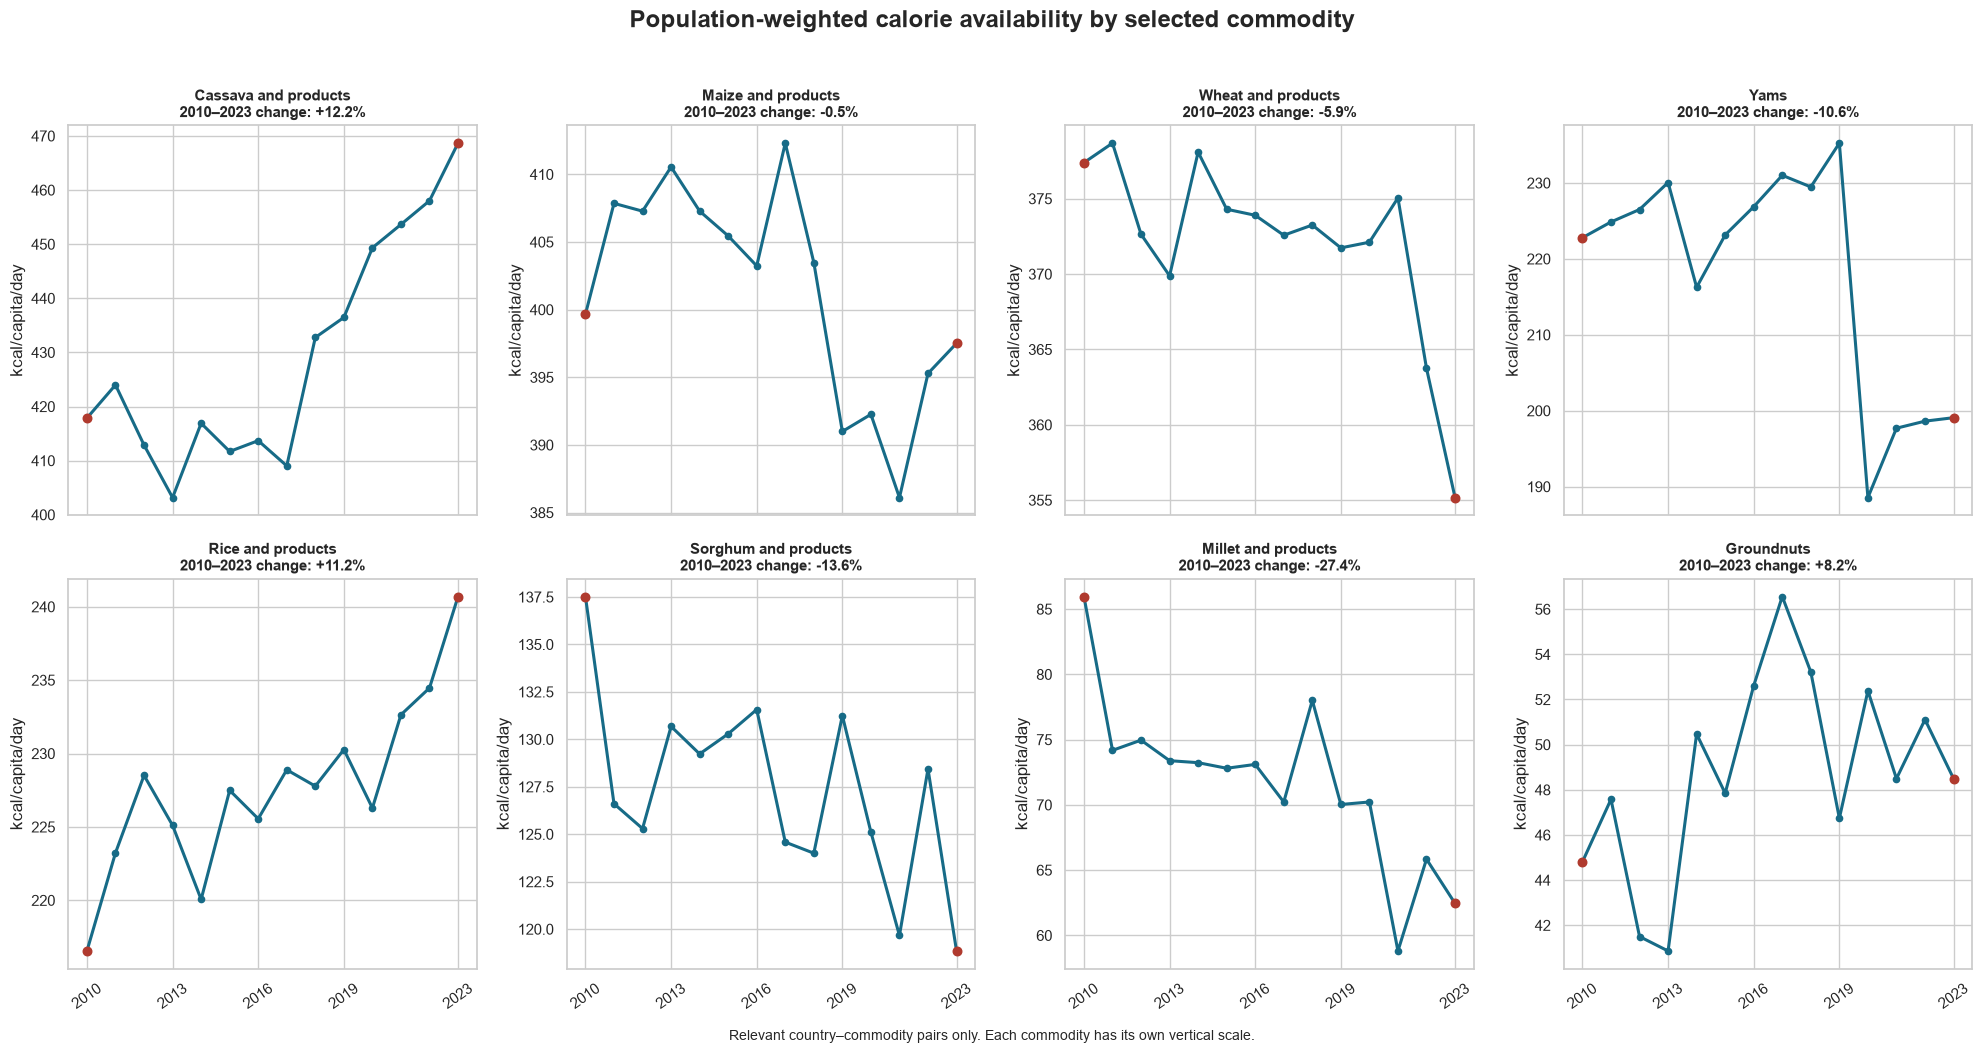

Annual population-weighted calorie trend chart created successfully.


In [28]:
# Block 24 — Annual population-weighted calorie trends
#
# Population weighting is calculated separately for every
# commodity-year using only countries with recorded calorie
# and positive population values.

import matplotlib.pyplot as plt
import seaborn as sns

calorie_trend_source = relevant_temporal_panel.loc[
    relevant_temporal_panel["food_supply_kcal_cap_day"].notna()
    & relevant_temporal_panel["Population"].notna()
    & relevant_temporal_panel["Population"].gt(0),
    [
        "Item Code",
        "Item",
        "Year",
        "Area",
        "Population",
        "food_supply_kcal_cap_day",
    ],
].copy()

calorie_trend_source["Weighted calorie numerator"] = (
    calorie_trend_source["food_supply_kcal_cap_day"]
    * calorie_trend_source["Population"]
)

annual_weighted_calorie = (
    calorie_trend_source
    .groupby(
        ["Item Code", "Item", "Year"],
        as_index=False,
        observed=True,
    )
    .agg(
        Population_represented=("Population", "sum"),
        Countries_represented=("Area", "nunique"),
        Weighted_calorie_numerator=(
            "Weighted calorie numerator",
            "sum",
        ),
    )
)

annual_weighted_calorie[
    "Population-weighted kcal/capita/day"
] = (
    annual_weighted_calorie["Weighted_calorie_numerator"]
    / annual_weighted_calorie["Population_represented"]
)

# Order commodities by their 2010 calorie contribution.
commodity_order = (
    annual_weighted_calorie[
        annual_weighted_calorie["Year"].eq(2010)
    ]
    .sort_values(
        "Population-weighted kcal/capita/day",
        ascending=False,
    )["Item"]
    .tolist()
)

assert len(commodity_order) == 8
assert len(annual_weighted_calorie) == 8 * 14

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(20, 10),
    sharex=True,
    sharey=False,
)

axes = axes.flatten()

for ax, commodity in zip(axes, commodity_order):
    plot_data = annual_weighted_calorie[
        annual_weighted_calorie["Item"].eq(commodity)
    ].sort_values("Year")

    ax.plot(
        plot_data["Year"],
        plot_data["Population-weighted kcal/capita/day"],
        marker="o",
        linewidth=2.2,
        markersize=4.5,
        color="#176B87",
    )

    first_value = plot_data.iloc[0][
        "Population-weighted kcal/capita/day"
    ]
    last_value = plot_data.iloc[-1][
        "Population-weighted kcal/capita/day"
    ]

    change_percentage = (
        (last_value - first_value) / first_value * 100
        if first_value != 0
        else np.nan
    )

    direction = "+" if change_percentage >= 0 else ""

    ax.set_title(
        f"{commodity}\n"
        f"2010–2023 change: {direction}{change_percentage:.1f}%",
        fontsize=11,
        fontweight="bold",
    )

    ax.set_xlabel("")
    ax.set_ylabel("kcal/capita/day")
    ax.set_xticks([2010, 2013, 2016, 2019, 2023])
    ax.tick_params(axis="x", rotation=35)

    ax.scatter(
        [plot_data.iloc[0]["Year"], plot_data.iloc[-1]["Year"]],
        [first_value, last_value],
        color="#B03A2E",
        s=38,
        zorder=3,
    )

fig.suptitle(
    "Population-weighted calorie availability by selected commodity",
    fontsize=17,
    fontweight="bold",
    y=1.02,
)

fig.text(
    0.5,
    -0.01,
    (
        "Relevant country–commodity pairs only. "
        "Each commodity has its own vertical scale."
    ),
    ha="center",
    fontsize=10,
)

plt.tight_layout()
plt.show()

print("Annual population-weighted calorie trend chart created successfully.")

In [29]:
# Block 25 — Identify annual turning points and temporal volatility
#
# This quantifies the largest annual fall, largest annual increase,
# lowest year, highest year and recent 2021–2023 movement for each
# commodity.

annual_calorie_diagnostics = (
    annual_weighted_calorie[
        [
            "Item Code",
            "Item",
            "Year",
            "Population-weighted kcal/capita/day",
            "Countries_represented",
        ]
    ]
    .sort_values(["Item Code", "Year"])
    .reset_index(drop=True)
)

annual_calorie_diagnostics["Annual change %"] = (
    annual_calorie_diagnostics
    .groupby("Item Code", observed=True)[
        "Population-weighted kcal/capita/day"
    ]
    .pct_change(fill_method=None)
    .mul(100)
)

turning_point_records = []

for (item_code, item), commodity_data in (
    annual_calorie_diagnostics.groupby(
        ["Item Code", "Item"],
        observed=True,
    )
):
    commodity_data = commodity_data.sort_values("Year").copy()

    annual_changes = commodity_data.dropna(
        subset=["Annual change %"]
    )

    largest_fall_row = annual_changes.loc[
        annual_changes["Annual change %"].idxmin()
    ]

    largest_increase_row = annual_changes.loc[
        annual_changes["Annual change %"].idxmax()
    ]

    lowest_row = commodity_data.loc[
        commodity_data[
            "Population-weighted kcal/capita/day"
        ].idxmin()
    ]

    highest_row = commodity_data.loc[
        commodity_data[
            "Population-weighted kcal/capita/day"
        ].idxmax()
    ]

    value_2021 = commodity_data.loc[
        commodity_data["Year"].eq(2021),
        "Population-weighted kcal/capita/day",
    ].iloc[0]

    value_2023 = commodity_data.loc[
        commodity_data["Year"].eq(2023),
        "Population-weighted kcal/capita/day",
    ].iloc[0]

    recent_change_percentage = (
        (value_2023 - value_2021) / value_2021 * 100
        if value_2021 != 0
        else np.nan
    )

    turning_point_records.append(
        {
            "Item Code": item_code,
            "Item": item,
            "Lowest year": int(lowest_row["Year"]),
            "Lowest kcal/capita/day":
                lowest_row[
                    "Population-weighted kcal/capita/day"
                ],
            "Highest year": int(highest_row["Year"]),
            "Highest kcal/capita/day":
                highest_row[
                    "Population-weighted kcal/capita/day"
                ],
            "Largest annual fall year":
                int(largest_fall_row["Year"]),
            "Largest annual fall %":
                largest_fall_row["Annual change %"],
            "Largest annual increase year":
                int(largest_increase_row["Year"]),
            "Largest annual increase %":
                largest_increase_row["Annual change %"],
            "Annual change volatility":
                annual_changes["Annual change %"].std(),
            "2021–2023 change %":
                recent_change_percentage,
            "Minimum countries represented":
                commodity_data["Countries_represented"].min(),
            "Maximum countries represented":
                commodity_data["Countries_represented"].max(),
        }
    )

commodity_turning_points = (
    pd.DataFrame(turning_point_records)
    .sort_values(
        "2021–2023 change %",
        ascending=False,
        na_position="last",
    )
    .reset_index(drop=True)
)

percentage_columns = [
    "Largest annual fall %",
    "Largest annual increase %",
    "Annual change volatility",
    "2021–2023 change %",
]

value_columns = [
    "Lowest kcal/capita/day",
    "Highest kcal/capita/day",
]

commodity_turning_points[
    percentage_columns + value_columns
] = commodity_turning_points[
    percentage_columns + value_columns
].round(2)

print("Commodity turning-point and volatility summary:")
display(commodity_turning_points)

assert len(commodity_turning_points) == 8

assert (
    commodity_turning_points["Largest annual fall %"] <= 0
).all()

assert (
    commodity_turning_points["Largest annual increase %"] >= 0
).all()

assert np.isfinite(
    commodity_turning_points[
        percentage_columns + value_columns
    ].to_numpy(dtype=float)
).all()

print(
    "\nCommodity turning-point and volatility audit "
    "completed successfully."
)

Commodity turning-point and volatility summary:


,Item Code,Item,Lowest year,Lowest kcal/capita/day,Highest year,Highest kcal/capita/day,Largest annual fall year,Largest annual fall %,Largest annual increase year,Largest annual increase %,Annual change volatility,2021–2023 change %,Minimum countries represented,Maximum countries represented
0,2517,Millet and products,2021,58.81,2010,85.96,2021,-16.26,2022,11.97,8.23,6.20,21,21
1,2807,Rice and products,2010,216.55,2023,240.70,2014,-2.24,2015,3.38,1.99,3.46,43,43
2,2532,Cassava and products,2013,403.17,2023,468.67,2012,-2.62,2018,5.80,2.39,3.31,28,28
3,2514,Maize and products,2021,386.11,2017,412.31,2019,-3.10,2022,2.38,1.68,2.95,41,41
4,2535,Yams,2020,188.56,2019,235.24,2020,-19.85,2021,4.85,6.29,0.70,13,13
5,2552,Groundnuts,2013,40.86,2017,56.56,2012,-12.78,2014,23.53,10.66,0.01,37,38
6,2518,Sorghum and products,2023,118.85,2010,137.52,2011,-7.94,2022,7.33,4.87,-0.68,25,25
7,2511,Wheat and products,2023,355.17,2011,378.69,2022,-3.01,2014,2.22,1.35,-5.30,43,43



Commodity turning-point and volatility audit completed successfully.


In [30]:
# Block 26 — Country-level annual calorie-change distribution
#
# Percentage changes are calculated only when the previous year's
# calorie value was at least 5 kcal/capita/day. This avoids producing
# misleading extreme percentages from values close to zero.

country_calorie_change = (
    relevant_temporal_panel[
        [
            "M49 Code",
            "Area",
            "Item Code",
            "Item",
            "Year",
            "food_supply_kcal_cap_day",
        ]
    ]
    .sort_values(["M49 Code", "Item Code", "Year"])
    .reset_index(drop=True)
)

pair_groups = country_calorie_change.groupby(
    ["M49 Code", "Item Code"],
    observed=True,
)

country_calorie_change["Previous year"] = (
    pair_groups["Year"].shift(1)
)

country_calorie_change["Previous kcal/capita/day"] = (
    pair_groups["food_supply_kcal_cap_day"].shift(1)
)

country_calorie_change["Consecutive year"] = (
    country_calorie_change["Year"]
    - country_calorie_change["Previous year"]
).eq(1)

country_calorie_change["Comparable transition"] = (
    country_calorie_change["Consecutive year"]
    & country_calorie_change[
        "Previous kcal/capita/day"
    ].notna()
    & country_calorie_change[
        "food_supply_kcal_cap_day"
    ].notna()
)

country_calorie_change["Annual kcal change"] = (
    country_calorie_change["food_supply_kcal_cap_day"]
    - country_calorie_change["Previous kcal/capita/day"]
)

country_calorie_change["Stable percentage base"] = (
    country_calorie_change["Comparable transition"]
    & country_calorie_change[
        "Previous kcal/capita/day"
    ].ge(5)
)

country_calorie_change["Annual kcal change %"] = np.where(
    country_calorie_change["Stable percentage base"],
    (
        country_calorie_change["Annual kcal change"]
        / country_calorie_change["Previous kcal/capita/day"]
        * 100
    ),
    np.nan,
)

expected_transitions = 252 * 13

transition_summary = pd.Series(
    {
        "Expected annual transitions": expected_transitions,
        "Comparable annual transitions":
            country_calorie_change[
                "Comparable transition"
            ].sum(),
        "Transitions without comparable values":
            expected_transitions
            - country_calorie_change[
                "Comparable transition"
            ].sum(),
        "Transitions with previous value below 5":
            (
                country_calorie_change["Comparable transition"]
                & country_calorie_change[
                    "Previous kcal/capita/day"
                ].lt(5)
            ).sum(),
        "Percentage-comparable transitions":
            country_calorie_change[
                "Annual kcal change %"
            ].notna().sum(),
        "Transitions showing any decline":
            (
                country_calorie_change["Comparable transition"]
                & country_calorie_change[
                    "Annual kcal change"
                ].lt(0)
            ).sum(),
        "Declines of at least 5 kcal/capita/day":
            (
                country_calorie_change["Comparable transition"]
                & country_calorie_change[
                    "Annual kcal change"
                ].le(-5)
            ).sum(),
        "Declines of at least 10 kcal/capita/day":
            (
                country_calorie_change["Comparable transition"]
                & country_calorie_change[
                    "Annual kcal change"
                ].le(-10)
            ).sum(),
        "Percentage declines of at least 5%":
            country_calorie_change[
                "Annual kcal change %"
            ].le(-5).sum(),
        "Percentage declines of at least 10%":
            country_calorie_change[
                "Annual kcal change %"
            ].le(-10).sum(),
        "Percentage declines of at least 20%":
            country_calorie_change[
                "Annual kcal change %"
            ].le(-20).sum(),
    },
    name="Result",
).to_frame()

print("Country-level annual transition summary:")
display(transition_summary)

comparable_changes = country_calorie_change.loc[
    country_calorie_change["Comparable transition"],
    "Annual kcal change",
]

absolute_change_distribution = (
    comparable_changes.quantile(
        [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .rename("Annual kcal change")
    .rename_axis("Quantile")
    .reset_index()
)

absolute_change_distribution["Quantile"] = (
    absolute_change_distribution["Quantile"] * 100
).astype(int).astype(str) + "th percentile"

absolute_change_distribution[
    "Annual kcal change"
] = absolute_change_distribution[
    "Annual kcal change"
].round(2)

print("\nDistribution of annual absolute calorie changes:")
display(absolute_change_distribution)

commodity_change_summary = (
    country_calorie_change[
        country_calorie_change["Comparable transition"]
    ]
    .groupby(
        ["Item Code", "Item"],
        observed=True,
    )
    .agg(
        Comparable_transitions=(
            "Annual kcal change",
            "count",
        ),
        Median_annual_change=(
            "Annual kcal change",
            "median",
        ),
        Tenth_percentile_change=(
            "Annual kcal change",
            lambda values: values.quantile(0.10),
        ),
        Ninetieth_percentile_change=(
            "Annual kcal change",
            lambda values: values.quantile(0.90),
        ),
        Minimum_annual_change=(
            "Annual kcal change",
            "min",
        ),
        Maximum_annual_change=(
            "Annual kcal change",
            "max",
        ),
        Annual_change_standard_deviation=(
            "Annual kcal change",
            "std",
        ),
        Declining_transitions=(
            "Annual kcal change",
            lambda values: values.lt(0).sum(),
        ),
        Declines_at_least_10_kcal=(
            "Annual kcal change",
            lambda values: values.le(-10).sum(),
        ),
    )
    .reset_index()
)

commodity_change_summary["Declining transition %"] = (
    commodity_change_summary["Declining_transitions"]
    / commodity_change_summary["Comparable_transitions"]
    * 100
)

commodity_change_summary["Decline at least 10 kcal %"] = (
    commodity_change_summary["Declines_at_least_10_kcal"]
    / commodity_change_summary["Comparable_transitions"]
    * 100
)

round_columns = [
    "Median_annual_change",
    "Tenth_percentile_change",
    "Ninetieth_percentile_change",
    "Minimum_annual_change",
    "Maximum_annual_change",
    "Annual_change_standard_deviation",
    "Declining transition %",
    "Decline at least 10 kcal %",
]

commodity_change_summary[round_columns] = (
    commodity_change_summary[round_columns].round(2)
)

commodity_change_summary = commodity_change_summary.sort_values(
    "Decline at least 10 kcal %",
    ascending=False,
).reset_index(drop=True)

print("\nAnnual calorie-change behaviour by commodity:")
display(commodity_change_summary)

assert len(commodity_change_summary) == 8

assert (
    country_calorie_change["Comparable transition"].sum()
    <= expected_transitions
)

print(
    "\nCountry-level annual calorie-change audit "
    "completed successfully."
)

Country-level annual transition summary:


,Result
Expected annual transitions,3276
Comparable annual transitions,3272
Transitions without comparable values,4
Transitions with previous value below 5,57
Percentage-comparable transitions,3215
Transitions showing any decline,1641
Declines of at least 5 kcal/capita/day,941
Declines of at least 10 kcal/capita/day,663
Percentage declines of at least 5%,887
Percentage declines of at least 10%,584



Distribution of annual absolute calorie changes:


,Quantile,Annual kcal change
0,1th percentile,-104.09
1,5th percentile,-43.65
2,10th percentile,-24.42
3,25th percentile,-6.69
4,50th percentile,-0.01
5,75th percentile,7.20
6,90th percentile,26.06
7,95th percentile,46.50
8,99th percentile,100.53



Annual calorie-change behaviour by commodity:


,Item Code,Item,Comparable_transitions,Median_annual_change,Tenth_percentile_change,Ninetieth_percentile_change,Minimum_annual_change,Maximum_annual_change,Annual_change_standard_deviation,Declining_transitions,Declines_at_least_10_kcal,Declining transition %,Decline at least 10 kcal %
0,2511,Wheat and products,559,-0.63,-31.65,35.45,-280.35,192.18,34.51,282,170,50.45,30.41
1,2514,Maize and products,533,-0.02,-40.12,33.03,-173.87,189.85,38.62,267,126,50.09,23.64
2,2807,Rice and products,559,1.11,-30.02,41.60,-210.73,183.60,36.83,252,130,45.08,23.26
3,2532,Cassava and products,364,-0.06,-21.91,29.36,-174.13,230.40,35.53,183,81,50.27,22.25
4,2518,Sorghum and products,325,-0.41,-21.72,14.52,-185.37,187.50,28.23,177,61,54.46,18.77
5,2517,Millet and products,273,-0.55,-15.22,7.81,-241.58,210.52,28.33,165,39,60.44,14.29
6,2552,Groundnuts,490,0.08,-10.58,10.71,-92.39,69.59,13.17,239,51,48.78,10.41
7,2535,Yams,169,0.01,-3.17,5.31,-77.91,61.66,9.80,76,5,44.97,2.96



Country-level annual calorie-change audit completed successfully.


In [31]:
# Block 27 — Compare candidate shortage-event thresholds
#
# These are diagnostic definitions only. No target is being finalised yet.
# Every definition requires:
#   1. a previous value of at least 5 kcal/capita/day;
#   2. a percentage decline threshold; and
#   3. an absolute decline threshold.

threshold_definitions = {
    "10% and 5 kcal decline": {
        "percentage": -10,
        "absolute": -5,
    },
    "15% and 5 kcal decline": {
        "percentage": -15,
        "absolute": -5,
    },
    "20% and 5 kcal decline": {
        "percentage": -20,
        "absolute": -5,
    },
    "10% and 10 kcal decline": {
        "percentage": -10,
        "absolute": -10,
    },
    "15% and 10 kcal decline": {
        "percentage": -15,
        "absolute": -10,
    },
    "20% and 10 kcal decline": {
        "percentage": -20,
        "absolute": -10,
    },
}

threshold_analysis = country_calorie_change[
    country_calorie_change["Stable percentage base"]
].copy()

for label, limits in threshold_definitions.items():
    threshold_analysis[label] = (
        threshold_analysis["Annual kcal change %"].le(
            limits["percentage"]
        )
        & threshold_analysis["Annual kcal change"].le(
            limits["absolute"]
        )
    )

overall_threshold_records = []

for label, limits in threshold_definitions.items():
    event_count = int(threshold_analysis[label].sum())
    comparable_count = len(threshold_analysis)

    overall_threshold_records.append(
        {
            "Candidate definition": label,
            "Percentage decline threshold":
                abs(limits["percentage"]),
            "Absolute decline threshold":
                abs(limits["absolute"]),
            "Comparable transitions": comparable_count,
            "Events": event_count,
            "Non-events": comparable_count - event_count,
            "Event rate %":
                event_count / comparable_count * 100,
            "Non-event to event ratio":
                (
                    (comparable_count - event_count) / event_count
                    if event_count > 0
                    else np.nan
                ),
        }
    )

overall_threshold_summary = pd.DataFrame(
    overall_threshold_records
)

overall_threshold_summary[
    ["Event rate %", "Non-event to event ratio"]
] = overall_threshold_summary[
    ["Event rate %", "Non-event to event ratio"]
].round(2)

print("Overall candidate-threshold comparison:")
display(overall_threshold_summary)

commodity_threshold_records = []

for (item_code, item), commodity_data in threshold_analysis.groupby(
    ["Item Code", "Item"],
    observed=True,
):
    record = {
        "Item Code": item_code,
        "Item": item,
        "Comparable transitions": len(commodity_data),
    }

    for label in threshold_definitions:
        event_count = int(commodity_data[label].sum())

        record[f"{label} events"] = event_count
        record[f"{label} rate %"] = (
            event_count / len(commodity_data) * 100
        )

    commodity_threshold_records.append(record)

commodity_threshold_summary = pd.DataFrame(
    commodity_threshold_records
).sort_values("Item Code").reset_index(drop=True)

rate_columns = [
    column
    for column in commodity_threshold_summary.columns
    if column.endswith("rate %")
]

commodity_threshold_summary[rate_columns] = (
    commodity_threshold_summary[rate_columns].round(2)
)

print("\nCandidate event rates by commodity:")
display(
    commodity_threshold_summary[
        [
            "Item Code",
            "Item",
            "Comparable transitions",
            *rate_columns,
        ]
    ]
)

year_threshold_records = []

for year, year_data in threshold_analysis.groupby(
    "Year",
    observed=True,
):
    record = {
        "Year": int(year),
        "Comparable transitions": len(year_data),
    }

    for label in threshold_definitions:
        event_count = int(year_data[label].sum())

        record[f"{label} events"] = event_count
        record[f"{label} rate %"] = (
            event_count / len(year_data) * 100
        )

    year_threshold_records.append(record)

year_threshold_summary = (
    pd.DataFrame(year_threshold_records)
    .sort_values("Year")
    .reset_index(drop=True)
)

year_rate_columns = [
    column
    for column in year_threshold_summary.columns
    if column.endswith("rate %")
]

year_threshold_summary[year_rate_columns] = (
    year_threshold_summary[year_rate_columns].round(2)
)

print("\nCandidate event rates by year:")
display(
    year_threshold_summary[
        [
            "Year",
            "Comparable transitions",
            *year_rate_columns,
        ]
    ]
)

assert len(overall_threshold_summary) == 6
assert len(commodity_threshold_summary) == 8
assert year_threshold_summary["Year"].min() == 2011
assert year_threshold_summary["Year"].max() == 2023

# Stricter definitions must never produce more events
# than their corresponding less strict definitions.
assert (
    threshold_analysis[
        "15% and 5 kcal decline"
    ].sum()
    <= threshold_analysis[
        "10% and 5 kcal decline"
    ].sum()
)

assert (
    threshold_analysis[
        "20% and 10 kcal decline"
    ].sum()
    <= threshold_analysis[
        "15% and 10 kcal decline"
    ].sum()
)

print(
    "\nCandidate shortage-threshold sensitivity "
    "analysis completed successfully."
)

Overall candidate-threshold comparison:


,Candidate definition,Percentage decline threshold,Absolute decline threshold,Comparable transitions,Events,Non-events,Event rate %,Non-event to event ratio
0,10% and 5 kcal decline,10,5,3215,453,2762,14.09,6.10
1,15% and 5 kcal decline,15,5,3215,330,2885,10.26,8.74
2,20% and 5 kcal decline,20,5,3215,244,2971,7.59,12.18
3,10% and 10 kcal decline,10,10,3215,343,2872,10.67,8.37
4,15% and 10 kcal decline,15,10,3215,249,2966,7.74,11.91
5,20% and 10 kcal decline,20,10,3215,184,3031,5.72,16.47



Candidate event rates by commodity:


,Item Code,Item,Comparable transitions,10% and 5 kcal decline rate %,15% and 5 kcal decline rate %,20% and 5 kcal decline rate %,10% and 10 kcal decline rate %,15% and 10 kcal decline rate %,20% and 10 kcal decline rate %
0,2511,Wheat and products,559,16.82,10.20,6.80,14.31,8.94,6.44
1,2514,Maize and products,526,13.50,9.70,6.46,10.27,7.03,4.56
2,2517,Millet and products,268,14.18,11.94,8.96,8.58,7.09,5.97
3,2518,Sorghum and products,319,21.63,18.18,15.36,15.67,14.11,12.23
4,2532,Cassava and products,362,9.94,6.63,5.25,8.56,5.80,4.42
5,2535,Yams,160,1.25,1.25,1.25,0.62,0.62,0.62
6,2552,Groundnuts,462,16.67,13.85,11.90,10.82,9.09,7.58
7,2807,Rice and products,559,11.81,7.51,4.11,9.66,6.08,3.04



Candidate event rates by year:


,Year,Comparable transitions,10% and 5 kcal decline rate %,15% and 5 kcal decline rate %,20% and 5 kcal decline rate %,10% and 10 kcal decline rate %,15% and 10 kcal decline rate %,20% and 10 kcal decline rate %
0,2011,244,13.52,10.25,7.38,10.66,7.79,5.33
1,2012,247,12.15,7.29,5.67,9.72,6.48,5.26
2,2013,247,14.57,10.53,8.10,9.31,7.29,6.07
3,2014,248,14.92,12.90,10.08,12.10,10.48,8.06
4,2015,248,13.71,10.08,6.85,10.48,7.66,5.24
5,2016,248,14.52,11.69,8.87,7.26,5.65,4.03
6,2017,247,8.91,5.67,3.24,8.50,5.26,2.83
7,2018,247,12.96,10.53,7.69,9.72,7.69,6.07
8,2019,249,17.67,13.65,9.24,12.85,10.04,6.02
9,2020,245,13.06,9.39,6.12,9.80,7.35,4.90



Candidate shortage-threshold sensitivity analysis completed successfully.


In [32]:
# Block 28 — Validate the provisional calorie-decline events
#
# Working event definition:
#   - previous calorie value is at least 5 kcal/capita/day;
#   - annual calorie decline is at least 15%;
#   - absolute decline is at least 5 kcal/capita/day.
#
# This remains a provisional target definition.

validation_columns = [
    "M49 Code",
    "Area",
    "Item Code",
    "Item",
    "Year",
    "food_supply_kcal_cap_day",
    "food_supply_quantity_kg_cap_yr",
    "food_1000t",
    "domestic_supply_1000t",
    "production_1000t",
    "import_quantity_1000t",
    "food_supply_kcal_cap_day_flag",
]

event_validation = (
    relevant_temporal_panel[validation_columns]
    .sort_values(["M49 Code", "Item Code", "Year"])
    .reset_index(drop=True)
)

event_groups = event_validation.groupby(
    ["M49 Code", "Item Code"],
    observed=True,
)

measures_to_compare = [
    "food_supply_kcal_cap_day",
    "food_supply_quantity_kg_cap_yr",
    "food_1000t",
    "domestic_supply_1000t",
    "production_1000t",
    "import_quantity_1000t",
]

for measure in measures_to_compare:
    event_validation[f"Previous {measure}"] = (
        event_groups[measure].shift(1)
    )

    event_validation[f"{measure} change"] = (
        event_validation[measure]
        - event_validation[f"Previous {measure}"]
    )

    valid_percentage_base = (
        event_validation[f"Previous {measure}"].notna()
        & event_validation[measure].notna()
        & event_validation[f"Previous {measure}"].gt(0)
    )

    event_validation[f"{measure} change %"] = np.where(
        valid_percentage_base,
        (
            event_validation[f"{measure} change"]
            / event_validation[f"Previous {measure}"]
            * 100
        ),
        np.nan,
    )

event_validation["Previous year"] = (
    event_groups["Year"].shift(1)
)

event_validation["Consecutive year"] = (
    event_validation["Year"]
    - event_validation["Previous year"]
).eq(1)

event_validation["Provisional shortage event"] = (
    event_validation["Consecutive year"]
    & event_validation[
        "Previous food_supply_kcal_cap_day"
    ].ge(5)
    & event_validation[
        "food_supply_kcal_cap_day change %"
    ].le(-15)
    & event_validation[
        "food_supply_kcal_cap_day change"
    ].le(-5)
)

provisional_events = event_validation[
    event_validation["Provisional shortage event"]
].copy()

food_kg_comparable = (
    provisional_events[
        "Previous food_supply_quantity_kg_cap_yr"
    ].notna()
    & provisional_events[
        "food_supply_quantity_kg_cap_yr"
    ].notna()
)

food_total_comparable = (
    provisional_events["Previous food_1000t"].notna()
    & provisional_events["food_1000t"].notna()
)

domestic_comparable = (
    provisional_events[
        "Previous domestic_supply_1000t"
    ].notna()
    & provisional_events[
        "domestic_supply_1000t"
    ].notna()
)

production_comparable = (
    provisional_events[
        "Previous production_1000t"
    ].notna()
    & provisional_events["production_1000t"].notna()
)

import_comparable = (
    provisional_events[
        "Previous import_quantity_1000t"
    ].notna()
    & provisional_events[
        "import_quantity_1000t"
    ].notna()
)

food_kg_decline = (
    provisional_events[
        "food_supply_quantity_kg_cap_yr change"
    ].lt(0)
)

food_total_decline = (
    provisional_events["food_1000t change"].lt(0)
)

domestic_decline = (
    provisional_events[
        "domestic_supply_1000t change"
    ].lt(0)
)

production_decline = (
    provisional_events["production_1000t change"].lt(0)
)

import_increase = (
    provisional_events[
        "import_quantity_1000t change"
    ].gt(0)
)

calorie_food_quantity_correlation = (
    provisional_events.loc[
        food_kg_comparable,
        [
            "food_supply_kcal_cap_day change %",
            "food_supply_quantity_kg_cap_yr change %",
        ],
    ]
    .dropna()
    .corr()
    .iloc[0, 1]
)

event_measure_summary = pd.Series(
    {
        "Provisional events": len(provisional_events),

        "Events with comparable per-capita food quantity":
            food_kg_comparable.sum(),
        "Comparable events with declining per-capita food quantity":
            (food_kg_comparable & food_kg_decline).sum(),
        "Per-capita food-quantity agreement %":
            (
                (food_kg_comparable & food_kg_decline).sum()
                / food_kg_comparable.sum()
                * 100
            ),

        "Events with comparable total food quantity":
            food_total_comparable.sum(),
        "Comparable events with declining total food quantity":
            (food_total_comparable & food_total_decline).sum(),
        "Total food-quantity decline %":
            (
                (food_total_comparable & food_total_decline).sum()
                / food_total_comparable.sum()
                * 100
            ),

        "Events with comparable domestic supply":
            domestic_comparable.sum(),
        "Comparable events with declining domestic supply":
            (domestic_comparable & domestic_decline).sum(),
        "Domestic-supply decline %":
            (
                (domestic_comparable & domestic_decline).sum()
                / domestic_comparable.sum()
                * 100
            ),

        "Events with comparable production":
            production_comparable.sum(),
        "Comparable events with declining production":
            (production_comparable & production_decline).sum(),
        "Production decline %":
            (
                (production_comparable & production_decline).sum()
                / production_comparable.sum()
                * 100
            ),

        "Events with comparable imports":
            import_comparable.sum(),
        "Comparable events with increasing imports":
            (import_comparable & import_increase).sum(),
        "Import increase %":
            (
                (import_comparable & import_increase).sum()
                / import_comparable.sum()
                * 100
            ),

        "Correlation: calorie change vs per-capita food change":
            calorie_food_quantity_correlation,
    },
    name="Result",
).to_frame()

percentage_summary_rows = [
    "Per-capita food-quantity agreement %",
    "Total food-quantity decline %",
    "Domestic-supply decline %",
    "Production decline %",
    "Import increase %",
    "Correlation: calorie change vs per-capita food change",
]

event_measure_summary.loc[
    percentage_summary_rows,
    "Result",
] = event_measure_summary.loc[
    percentage_summary_rows,
    "Result",
].round(2)

print("Provisional-event measure agreement:")
display(event_measure_summary)

# Three largest proportional declines for each commodity
largest_event_examples = (
    provisional_events
    .sort_values(
        ["Item Code", "food_supply_kcal_cap_day change %"]
    )
    .groupby(
        ["Item Code", "Item"],
        observed=True,
        group_keys=False,
    )
    .head(3)
    .reset_index(drop=True)
)

event_example_columns = [
    "Area",
    "Item",
    "Year",
    "Previous food_supply_kcal_cap_day",
    "food_supply_kcal_cap_day",
    "food_supply_kcal_cap_day change",
    "food_supply_kcal_cap_day change %",
    "Previous food_supply_quantity_kg_cap_yr",
    "food_supply_quantity_kg_cap_yr",
    "food_supply_quantity_kg_cap_yr change %",
    "Previous domestic_supply_1000t",
    "domestic_supply_1000t",
    "domestic_supply_1000t change %",
]

event_examples = largest_event_examples[
    event_example_columns
].copy()

numeric_example_columns = [
    column
    for column in event_examples.columns
    if column not in ["Area", "Item", "Year"]
]

event_examples[numeric_example_columns] = (
    event_examples[numeric_example_columns].round(2)
)

print("\nThree largest provisional events per commodity:")
display(event_examples)

assert len(provisional_events) == 330

assert (
    provisional_events[
        "food_supply_kcal_cap_day change %"
    ].le(-15)
).all()

assert (
    provisional_events[
        "food_supply_kcal_cap_day change"
    ].le(-5)
).all()

print(
    "\nProvisional shortage events validated against "
    "related analytical measures."
)

Provisional-event measure agreement:


,Result
Provisional events,330.00
Events with comparable per-capita food quantity,330.00
Comparable events with declining per-capita food quantity,329.00
Per-capita food-quantity agreement %,99.70
Events with comparable total food quantity,330.00
Comparable events with declining total food quantity,325.00
Total food-quantity decline %,98.48
Events with comparable domestic supply,330.00
Comparable events with declining domestic supply,303.00
Domestic-supply decline %,91.82



Three largest provisional events per commodity:


,Area,Item,Year,Previous food_supply_kcal_cap_day,food_supply_kcal_cap_day,food_supply_kcal_cap_day change,food_supply_kcal_cap_day change %,Previous food_supply_quantity_kg_cap_yr,food_supply_quantity_kg_cap_yr,food_supply_quantity_kg_cap_yr change %,Previous domestic_supply_1000t,domestic_supply_1000t,domestic_supply_1000t change %
0,Malawi,Wheat and products,2022,41.56,17.58,-23.98,-57.70,5.80,2.45,-57.76,129.00,56.00,-56.59
1,Liberia,Wheat and products,2015,70.43,31.87,-38.56,-54.75,11.01,5.65,-48.68,50.00,26.00,-48.00
2,Rwanda,Wheat and products,2020,79.21,40.29,-38.92,-49.14,10.68,5.53,-48.22,139.00,69.00,-50.36
3,Djibouti,Maize and products,2014,7.95,1.84,-6.11,-76.86,1.08,0.25,-76.85,7.00,1.00,-85.71
4,Djibouti,Maize and products,2021,11.25,2.91,-8.34,-74.13,1.52,0.40,-73.68,9.00,3.00,-66.67
5,Mauritania,Maize and products,2013,70.95,21.84,-49.11,-69.22,8.12,2.50,-69.21,36.00,11.00,-69.44
6,Mozambique,Millet and products,2015,11.91,3.38,-8.53,-71.62,1.37,0.39,-71.53,39.00,11.00,-71.79
7,Angola,Millet and products,2012,16.67,4.81,-11.86,-71.15,1.92,0.55,-71.35,61.00,18.00,-70.49
8,Kenya,Millet and products,2020,20.21,8.46,-11.75,-58.14,2.20,0.97,-55.91,156.00,94.00,-39.74
9,Uganda,Sorghum and products,2019,8.42,0.00,-8.42,-100.00,0.96,0.00,-100.00,191.00,50.00,-73.82



Provisional shortage events validated against related analytical measures.


In [33]:
# Block 29 — Determine whether provisional events persisted or recovered
#
# This examines the year after each provisional event.
# Events occurring in 2023 cannot yet be followed because 2024
# is outside the dataset.

persistence_panel = event_validation.copy()

persistence_groups = persistence_panel.groupby(
    ["M49 Code", "Item Code"],
    observed=True,
)

persistence_panel["Next year"] = (
    persistence_groups["Year"].shift(-1)
)

persistence_panel["Next kcal/capita/day"] = (
    persistence_groups[
        "food_supply_kcal_cap_day"
    ].shift(-1)
)

persistence_panel["Next-year flag"] = (
    persistence_groups[
        "food_supply_kcal_cap_day_flag"
    ].shift(-1)
)

persistence_events = persistence_panel[
    persistence_panel["Provisional shortage event"]
].copy()

persistence_events["Follow-up available"] = (
    persistence_events["Next year"]
    .sub(persistence_events["Year"])
    .eq(1)
    & persistence_events[
        "Next kcal/capita/day"
    ].notna()
)

# The amount lost during the event year.
persistence_events["Event loss"] = (
    persistence_events[
        "Previous food_supply_kcal_cap_day"
    ]
    - persistence_events[
        "food_supply_kcal_cap_day"
    ]
)

# Percentage of the lost amount recovered in the following year.
persistence_events["Recovery of lost amount %"] = np.where(
    persistence_events["Follow-up available"]
    & persistence_events["Event loss"].gt(0),
    (
        persistence_events["Next kcal/capita/day"]
        - persistence_events["food_supply_kcal_cap_day"]
    )
    / persistence_events["Event loss"]
    * 100,
    np.nan,
)

follow_up = persistence_events["Follow-up available"]

previous_value = persistence_events[
    "Previous food_supply_kcal_cap_day"
]

event_value = persistence_events[
    "food_supply_kcal_cap_day"
]

next_value = persistence_events[
    "Next kcal/capita/day"
]

persistence_events["Post-event outcome"] = np.select(
    [
        ~follow_up,
        follow_up & next_value.lt(event_value),
        (
            follow_up
            & next_value.ge(event_value)
            & next_value.lt(previous_value * 0.90)
        ),
        (
            follow_up
            & next_value.ge(previous_value * 0.90)
            & next_value.lt(previous_value)
        ),
        follow_up & next_value.ge(previous_value),
    ],
    [
        "No next-year observation",
        "Further decline",
        "Partial recovery; still below 90% of pre-event value",
        "Near recovery; 90% to below 100% of pre-event value",
        "Full recovery to at least the pre-event value",
    ],
    default="Unclassified",
)

post_event_summary = (
    persistence_events["Post-event outcome"]
    .value_counts(dropna=False)
    .rename_axis("Post-event outcome")
    .reset_index(name="Events")
)

post_event_summary["Percentage of all events"] = (
    post_event_summary["Events"]
    / len(persistence_events)
    * 100
).round(2)

followed_events = persistence_events[
    persistence_events["Follow-up available"]
]

post_event_summary["Percentage of followed events"] = np.where(
    post_event_summary["Post-event outcome"].eq(
        "No next-year observation"
    ),
    np.nan,
    (
        post_event_summary["Events"]
        / len(followed_events)
        * 100
    ).round(2),
)

print("Post-event persistence and recovery summary:")
display(post_event_summary)

commodity_persistence = (
    persistence_events[
        persistence_events["Follow-up available"]
    ]
    .groupby(
        ["Item Code", "Item", "Post-event outcome"],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

expected_outcome_columns = [
    "Further decline",
    "Partial recovery; still below 90% of pre-event value",
    "Near recovery; 90% to below 100% of pre-event value",
    "Full recovery to at least the pre-event value",
]

for column in expected_outcome_columns:
    if column not in commodity_persistence.columns:
        commodity_persistence[column] = 0

commodity_persistence["Followed events"] = (
    commodity_persistence[expected_outcome_columns].sum(axis=1)
)

commodity_persistence["Persistent or further decline %"] = (
    (
        commodity_persistence["Further decline"]
        + commodity_persistence[
            "Partial recovery; still below 90% of pre-event value"
        ]
    )
    / commodity_persistence["Followed events"]
    * 100
).round(2)

commodity_persistence["Near or full recovery %"] = (
    (
        commodity_persistence[
            "Near recovery; 90% to below 100% of pre-event value"
        ]
        + commodity_persistence[
            "Full recovery to at least the pre-event value"
        ]
    )
    / commodity_persistence["Followed events"]
    * 100
).round(2)

commodity_persistence = commodity_persistence[
    [
        "Item Code",
        "Item",
        "Followed events",
        *expected_outcome_columns,
        "Persistent or further decline %",
        "Near or full recovery %",
    ]
].sort_values(
    "Persistent or further decline %",
    ascending=False,
).reset_index(drop=True)

print("\nPost-event outcomes by commodity:")
display(commodity_persistence)

recovery_distribution = (
    followed_events["Recovery of lost amount %"]
    .quantile(
        [0.10, 0.25, 0.50, 0.75, 0.90]
    )
    .rename("Recovery of lost amount %")
    .rename_axis("Quantile")
    .reset_index()
)

recovery_distribution["Quantile"] = (
    recovery_distribution["Quantile"]
    .mul(100)
    .astype(int)
    .astype(str)
    + "th percentile"
)

recovery_distribution[
    "Recovery of lost amount %"
] = recovery_distribution[
    "Recovery of lost amount %"
].round(2)

print("\nDistribution of next-year recovery:")
display(recovery_distribution)

assert len(persistence_events) == 330

assert (
    persistence_events["Post-event outcome"]
    != "Unclassified"
).all()

assert (
    post_event_summary["Events"].sum()
    == len(persistence_events)
)

print(
    "\nPost-event persistence and recovery audit "
    "completed successfully."
)

Post-event persistence and recovery summary:


,Post-event outcome,Events,Percentage of all events,Percentage of followed events
0,Further decline,112,33.94,36.84
1,Partial recovery; still below 90% of pre-event...,107,32.42,35.20
2,Full recovery to at least the pre-event value,56,16.97,18.42
3,Near recovery; 90% to below 100% of pre-event ...,29,8.79,9.54
4,No next-year observation,26,7.88,NaN



Post-event outcomes by commodity:


Post-event outcome,Item Code,Item,Followed events,Further decline,Partial recovery; still below 90% of pre-event value,Near recovery; 90% to below 100% of pre-event value,Full recovery to at least the pre-event value,Persistent or further decline %,Near or full recovery %
0,2535,Yams,2,1,1,0,0,100.00,0.00
1,2517,Millet and products,30,10,16,1,3,86.67,13.33
2,2518,Sorghum and products,52,19,21,2,10,76.92,23.08
3,2552,Groundnuts,59,24,20,3,12,74.58,25.42
4,2514,Maize and products,48,17,16,8,7,68.75,31.25
5,2511,Wheat and products,51,20,14,6,11,66.67,33.33
6,2532,Cassava and products,23,7,8,2,6,65.22,34.78
7,2807,Rice and products,39,14,11,7,7,64.10,35.90



Distribution of next-year recovery:


,Quantile,Recovery of lost amount %
0,10th percentile,-53.73
1,25th percentile,-17.24
2,50th percentile,15.60
3,75th percentile,71.19
4,90th percentile,142.18



Post-event persistence and recovery audit completed successfully.


In [34]:
# Block 30 — Construct the leakage-safe next-year shortage target
#
# Each row is anchored in predictor year t.
# The target describes whether a material contraction occurs in t+1.
#
# Target = 1 when:
#   - calorie availability at t is at least 5 kcal/capita/day;
#   - calorie availability falls by at least 15% in t+1; and
#   - the absolute fall is at least 5 kcal/capita/day.
#
# Rows that cannot be evaluated are left as <NA>, not labelled zero.

model_panel = (
    final_panel
    .sort_values(["M49 Code", "Item Code", "Year"])
    .reset_index(drop=True)
    .copy()
)

model_groups = model_panel.groupby(
    ["M49 Code", "Item Code"],
    observed=True,
)

model_panel["target_year"] = (
    model_groups["Year"].shift(-1)
)

model_panel["next_year_kcal_cap_day"] = (
    model_groups[
        "food_supply_kcal_cap_day"
    ].shift(-1)
)

model_panel["next_year_kcal_flag"] = (
    model_groups[
        "food_supply_kcal_cap_day_flag"
    ].shift(-1)
)

model_panel["consecutive_target_year"] = (
    model_panel["target_year"]
    .sub(model_panel["Year"])
    .eq(1)
)

model_panel["next_year_kcal_change"] = (
    model_panel["next_year_kcal_cap_day"]
    - model_panel["food_supply_kcal_cap_day"]
)

model_panel["next_year_kcal_change_pct"] = np.where(
    model_panel["food_supply_kcal_cap_day"].gt(0)
    & model_panel["next_year_kcal_cap_day"].notna(),
    (
        model_panel["next_year_kcal_change"]
        / model_panel["food_supply_kcal_cap_day"]
        * 100
    ),
    np.nan,
)

model_panel["target_eligible"] = (
    model_panel["consecutive_target_year"]
    & model_panel[
        "food_supply_kcal_cap_day"
    ].notna()
    & model_panel[
        "next_year_kcal_cap_day"
    ].notna()
    & model_panel[
        "food_supply_kcal_cap_day"
    ].ge(5)
)

material_contraction = (
    model_panel["next_year_kcal_change_pct"].le(-15)
    & model_panel["next_year_kcal_change"].le(-5)
)

model_panel["shortage_next_year"] = pd.Series(
    pd.NA,
    index=model_panel.index,
    dtype="Int8",
)

model_panel.loc[
    model_panel["target_eligible"],
    "shortage_next_year",
] = (
    material_contraction.loc[
        model_panel["target_eligible"]
    ]
    .astype("int8")
)

eligible_target_panel = model_panel[
    model_panel["target_eligible"]
].copy()

positive_events = int(
    eligible_target_panel["shortage_next_year"].sum()
)

negative_events = int(
    eligible_target_panel["shortage_next_year"].eq(0).sum()
)

target_summary = pd.Series(
    {
        "Complete panel rows": len(model_panel),
        "Country-commodity pairs":
            model_panel[
                ["M49 Code", "Item Code"]
            ].drop_duplicates().shape[0],
        "Rows with a consecutive following year":
            model_panel["consecutive_target_year"].sum(),
        "Target-eligible rows":
            model_panel["target_eligible"].sum(),
        "Target-ineligible rows":
            (~model_panel["target_eligible"]).sum(),
        "Positive next-year shortage events":
            positive_events,
        "Negative next-year outcomes":
            negative_events,
        "Positive event rate %":
            positive_events / len(eligible_target_panel) * 100,
        "Non-event to event ratio":
            (
                negative_events / positive_events
                if positive_events > 0
                else np.nan
            ),
        "Earliest predictor year":
            eligible_target_panel["Year"].min(),
        "Latest predictor year":
            eligible_target_panel["Year"].max(),
        "Earliest target year":
            eligible_target_panel["target_year"].min(),
        "Latest target year":
            eligible_target_panel["target_year"].max(),
        "Eligible rows with missing target":
            eligible_target_panel[
                "shortage_next_year"
            ].isna().sum(),
        "Ineligible rows incorrectly labelled":
            model_panel.loc[
                ~model_panel["target_eligible"],
                "shortage_next_year",
            ].notna().sum(),
    },
    name="Result",
).to_frame()

target_summary.loc[
    ["Positive event rate %", "Non-event to event ratio"],
    "Result",
] = target_summary.loc[
    ["Positive event rate %", "Non-event to event ratio"],
    "Result",
].round(2)

print("Leakage-safe target summary:")
display(target_summary)

target_by_commodity = (
    eligible_target_panel
    .groupby(
        ["Item Code", "Item"],
        observed=True,
    )
    .agg(
        Eligible_transitions=(
            "shortage_next_year",
            "size",
        ),
        Positive_events=(
            "shortage_next_year",
            "sum",
        ),
    )
    .reset_index()
)

target_by_commodity["Negative_events"] = (
    target_by_commodity["Eligible_transitions"]
    - target_by_commodity["Positive_events"]
)

target_by_commodity["Event rate %"] = (
    target_by_commodity["Positive_events"]
    / target_by_commodity["Eligible_transitions"]
    * 100
).round(2)

target_by_commodity = target_by_commodity.sort_values(
    "Event rate %",
    ascending=False,
).reset_index(drop=True)

print("\nLeakage-safe target by commodity:")
display(target_by_commodity)

target_by_year = (
    eligible_target_panel
    .groupby("target_year", observed=True)
    .agg(
        Eligible_transitions=(
            "shortage_next_year",
            "size",
        ),
        Positive_events=(
            "shortage_next_year",
            "sum",
        ),
    )
    .reset_index()
    .rename(columns={"target_year": "Target year"})
)

target_by_year["Negative_events"] = (
    target_by_year["Eligible_transitions"]
    - target_by_year["Positive_events"]
)

target_by_year["Event rate %"] = (
    target_by_year["Positive_events"]
    / target_by_year["Eligible_transitions"]
    * 100
).round(2)

print("\nLeakage-safe target by outcome year:")
display(target_by_year)

assert len(model_panel) == 43 * 8 * 14
assert model_panel["shortage_next_year"].dropna().isin([0, 1]).all()

assert (
    eligible_target_panel["shortage_next_year"].notna()
).all()

assert (
    model_panel.loc[
        ~model_panel["target_eligible"],
        "shortage_next_year",
    ].isna()
).all()

assert (
    eligible_target_panel["target_year"]
    == eligible_target_panel["Year"] + 1
).all()

assert (
    eligible_target_panel.loc[
        eligible_target_panel["shortage_next_year"].eq(1),
        "next_year_kcal_change_pct",
    ].le(-15)
).all()

assert (
    eligible_target_panel.loc[
        eligible_target_panel["shortage_next_year"].eq(1),
        "next_year_kcal_change",
    ].le(-5)
).all()

print(
    "\nLeakage-safe next-year target constructed "
    "and validated successfully."
)

Leakage-safe target summary:


,Result
Complete panel rows,"4,816.00"
Country-commodity pairs,344.00
Rows with a consecutive following year,"4,472.00"
Target-eligible rows,"3,248.00"
Target-ineligible rows,"1,568.00"
Positive next-year shortage events,334.00
Negative next-year outcomes,"2,914.00"
Positive event rate %,10.28
Non-event to event ratio,8.72
Earliest predictor year,"2,010.00"



Leakage-safe target by commodity:


,Item Code,Item,Eligible_transitions,Positive_events,Negative_events,Event rate %
0,2518,Sorghum and products,333,59,274,17.72
1,2552,Groundnuts,464,64,400,13.79
2,2517,Millet and products,280,34,246,12.14
3,2511,Wheat and products,559,57,502,10.20
4,2514,Maize and products,528,51,477,9.66
5,2807,Rice and products,559,42,517,7.51
6,2532,Cassava and products,362,24,338,6.63
7,2535,Yams,163,3,160,1.84



Leakage-safe target by outcome year:


,Target year,Eligible_transitions,Positive_events,Negative_events,Event rate %
0,"2,011.00",249,25,224,10.04
1,"2,012.00",251,18,233,7.17
2,"2,013.00",252,27,225,10.71
3,"2,014.00",251,32,219,12.75
4,"2,015.00",250,26,224,10.40
5,"2,016.00",249,29,220,11.65
6,"2,017.00",249,14,235,5.62
7,"2,018.00",249,26,223,10.44
8,"2,019.00",250,34,216,13.60
9,"2,020.00",246,24,222,9.76



Leakage-safe next-year target constructed and validated successfully.


In [35]:
# Block 31 — Audit the proposed temporal train-validation-test split
#
# Splitting is based on target year because the prediction concerns
# an outcome occurring in the following year.
#
# Train:      target years 2011–2019
# Validation: target years 2020–2021
# Test:       target years 2022–2023

def assign_temporal_split(target_year):
    if 2011 <= target_year <= 2019:
        return "Train"
    if 2020 <= target_year <= 2021:
        return "Validation"
    if 2022 <= target_year <= 2023:
        return "Test"
    return pd.NA


eligible_target_panel["Temporal split"] = (
    eligible_target_panel["target_year"]
    .apply(assign_temporal_split)
    .astype("string")
)

split_order = ["Train", "Validation", "Test"]

split_summary = (
    eligible_target_panel
    .groupby(
        "Temporal split",
        observed=True,
    )
    .agg(
        Predictor_year_start=("Year", "min"),
        Predictor_year_end=("Year", "max"),
        Target_year_start=("target_year", "min"),
        Target_year_end=("target_year", "max"),
        Eligible_rows=("shortage_next_year", "size"),
        Positive_events=("shortage_next_year", "sum"),
        Countries=("Area", "nunique"),
        Commodities=("Item", "nunique"),
        Country_commodity_pairs=(
            "Item Code",
            lambda values: (
                eligible_target_panel.loc[
                    values.index,
                    ["M49 Code", "Item Code"],
                ]
                .drop_duplicates()
                .shape[0]
            ),
        ),
    )
    .reindex(split_order)
    .reset_index()
)

split_summary["Negative_events"] = (
    split_summary["Eligible_rows"]
    - split_summary["Positive_events"]
)

split_summary["Event rate %"] = (
    split_summary["Positive_events"]
    / split_summary["Eligible_rows"]
    * 100
).round(2)

split_summary["Non-event to event ratio"] = (
    split_summary["Negative_events"]
    / split_summary["Positive_events"]
).round(2)

split_summary = split_summary[
    [
        "Temporal split",
        "Predictor_year_start",
        "Predictor_year_end",
        "Target_year_start",
        "Target_year_end",
        "Eligible_rows",
        "Positive_events",
        "Negative_events",
        "Event rate %",
        "Non-event to event ratio",
        "Countries",
        "Commodities",
        "Country_commodity_pairs",
    ]
]

print("Proposed temporal split summary:")
display(split_summary)

commodity_split_summary = (
    eligible_target_panel
    .groupby(
        ["Temporal split", "Item Code", "Item"],
        observed=True,
    )
    .agg(
        Eligible_rows=("shortage_next_year", "size"),
        Positive_events=("shortage_next_year", "sum"),
    )
    .reset_index()
)

commodity_split_summary["Event rate %"] = (
    commodity_split_summary["Positive_events"]
    / commodity_split_summary["Eligible_rows"]
    * 100
).round(2)

commodity_split_summary["Temporal split"] = pd.Categorical(
    commodity_split_summary["Temporal split"],
    categories=split_order,
    ordered=True,
)

commodity_split_summary = (
    commodity_split_summary
    .sort_values(["Item Code", "Temporal split"])
    .reset_index(drop=True)
)

print("\nCommodity event balance within each temporal split:")
display(commodity_split_summary)

assert eligible_target_panel["Temporal split"].notna().all()

assert (
    split_summary["Eligible_rows"].sum()
    == len(eligible_target_panel)
)

assert (
    split_summary["Positive_events"].sum()
    == positive_events
)

assert (
    split_summary["Commodities"].eq(8)
).all()

assert (
    split_summary["Target_year_end"]
    < split_summary["Target_year_start"].shift(-1)
).dropna().all()

print(
    "\nTemporal split feasibility audit "
    "completed successfully."
)

Proposed temporal split summary:


,Temporal split,Predictor_year_start,Predictor_year_end,Target_year_start,Target_year_end,Eligible_rows,Positive_events,Negative_events,Event rate %,Non-event to event ratio,Countries,Commodities,Country_commodity_pairs
0,Train,2010,2018,"2,011.00","2,019.00",2250,231,2019,10.27,8.74,43,8,259
1,Validation,2019,2020,"2,020.00","2,021.00",500,52,448,10.40,8.62,43,8,254
2,Test,2021,2022,"2,022.00","2,023.00",498,51,447,10.24,8.76,43,8,255



Commodity event balance within each temporal split:


,Temporal split,Item Code,Item,Eligible_rows,Positive_events,Event rate %
0,Train,2511,Wheat and products,387,35,9.04
1,Validation,2511,Wheat and products,86,10,11.63
2,Test,2511,Wheat and products,86,12,13.95
3,Train,2514,Maize and products,365,36,9.86
4,Validation,2514,Maize and products,82,9,10.98
5,Test,2514,Maize and products,81,6,7.41
6,Train,2517,Millet and products,195,23,11.79
7,Validation,2517,Millet and products,42,8,19.05
8,Test,2517,Millet and products,43,3,6.98
9,Train,2518,Sorghum and products,231,40,17.32


AssertionError: 

In [36]:
# Block 31B — Correct temporal-boundary validation
#
# Compare each split's ending target year with the following
# split's starting target year. The final split has no successor,
# so it is deliberately excluded.

current_split_ends = (
    split_summary["Target_year_end"]
    .iloc[:-1]
    .to_numpy()
)

following_split_starts = (
    split_summary["Target_year_start"]
    .iloc[1:]
    .to_numpy()
)

assert (
    current_split_ends < following_split_starts
).all()

assert split_summary.loc[
    split_summary["Temporal split"].eq("Train"),
    "Target_year_end",
].iloc[0] < split_summary.loc[
    split_summary["Temporal split"].eq("Validation"),
    "Target_year_start",
].iloc[0]

assert split_summary.loc[
    split_summary["Temporal split"].eq("Validation"),
    "Target_year_end",
].iloc[0] < split_summary.loc[
    split_summary["Temporal split"].eq("Test"),
    "Target_year_start",
].iloc[0]

print(
    "Temporal split boundaries validated successfully.\n"
    "Train, validation and test target years do not overlap."
)

Temporal split boundaries validated successfully.
Train, validation and test target years do not overlap.


In [37]:
# Block 32 — Save the analytical and supervised panels
#
# The supervised panel deliberately excludes:
#   - next year's calorie value;
#   - next year's calorie flag;
#   - next-year absolute and percentage changes;
#   - target eligibility calculations.
#
# Only target_year, Temporal split and shortage_next_year are
# added to the current-year analytical columns.

from pathlib import Path

AFRICA_FIRST_DIR = Path(
    "/Users/adewale/Documents/food_security_predictor/"
    "data/processed/africa_first"
)

AFRICA_FIRST_DIR.mkdir(parents=True, exist_ok=True)

ANALYTICAL_PANEL_PATH = (
    AFRICA_FIRST_DIR
    / "africa_analytical_panel_2010_2023.parquet"
)

SUPERVISED_PANEL_PATH = (
    AFRICA_FIRST_DIR
    / "africa_supervised_shortage_panel_2010_2022.parquet"
)

TARGET_DEFINITION_PATH = (
    AFRICA_FIRST_DIR
    / "shortage_target_definition.csv"
)

TEMPORAL_SPLIT_PATH = (
    AFRICA_FIRST_DIR
    / "shortage_temporal_split_summary.csv"
)

TARGET_COMMODITY_PATH = (
    AFRICA_FIRST_DIR
    / "shortage_target_by_commodity.csv"
)

TARGET_YEAR_PATH = (
    AFRICA_FIRST_DIR
    / "shortage_target_by_year.csv"
)


# ------------------------------------------------------------
# 1. Complete analytical panel
# ------------------------------------------------------------

analytical_panel_to_save = (
    final_panel
    .sort_values(
        ["M49 Code", "Item Code", "Year"]
    )
    .reset_index(drop=True)
    .copy()
)

analytical_panel_to_save.columns.name = None


# ------------------------------------------------------------
# 2. Leakage-safe supervised panel
# ------------------------------------------------------------

supervised_columns = [
    *analytical_panel_to_save.columns.tolist(),
    "target_year",
    "Temporal split",
    "shortage_next_year",
]

supervised_panel_to_save = (
    eligible_target_panel[supervised_columns]
    .sort_values(
        ["M49 Code", "Item Code", "Year"]
    )
    .reset_index(drop=True)
    .copy()
)

supervised_panel_to_save.columns.name = None

supervised_panel_to_save["target_year"] = (
    supervised_panel_to_save["target_year"]
    .astype("int16")
)

supervised_panel_to_save["shortage_next_year"] = (
    supervised_panel_to_save["shortage_next_year"]
    .astype("int8")
)

supervised_panel_to_save["Temporal split"] = (
    supervised_panel_to_save["Temporal split"]
    .astype("string")
)


# ------------------------------------------------------------
# 3. Target-definition metadata
# ------------------------------------------------------------

target_definition = pd.DataFrame(
    [
        {
            "Target column": "shortage_next_year",
            "Prediction horizon": "One year ahead",
            "Predictor row year": "Year t",
            "Outcome year": "Year t + 1",
            "Minimum current kcal/capita/day": 5,
            "Minimum percentage decline": 15,
            "Minimum absolute decline kcal/capita/day": 5,
            "Positive definition": (
                "Next-year food supply kcal/capita/day falls "
                "by at least 15% and at least 5 kcal/capita/day"
            ),
            "Negative definition": (
                "Eligible transition that does not satisfy "
                "both decline conditions"
            ),
            "Ineligible treatment": (
                "Target left missing; row excluded from "
                "supervised modelling panel"
            ),
            "Training target years": "2011–2019",
            "Validation target years": "2020–2021",
            "Test target years": "2022–2023",
            "Future relevance used as feature": False,
            "Next-year outcome values included as features": False,
        }
    ]
)


# ------------------------------------------------------------
# 4. Validate before saving
# ------------------------------------------------------------

forbidden_supervised_columns = {
    "next_year_kcal_cap_day",
    "next_year_kcal_flag",
    "next_year_kcal_change",
    "next_year_kcal_change_pct",
    "target_eligible",
    "consecutive_target_year",
}

assert forbidden_supervised_columns.isdisjoint(
    supervised_panel_to_save.columns
)

assert len(analytical_panel_to_save) == 4816
assert len(supervised_panel_to_save) == 3248

assert (
    analytical_panel_to_save[
        ["M49 Code", "Item Code", "Year"]
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    supervised_panel_to_save[
        ["M49 Code", "Item Code", "Year"]
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    supervised_panel_to_save[
        "shortage_next_year"
    ].sum()
    == 334
)

assert (
    supervised_panel_to_save["target_year"]
    == supervised_panel_to_save["Year"] + 1
).all()

assert supervised_panel_to_save["Year"].min() == 2010
assert supervised_panel_to_save["Year"].max() == 2022
assert supervised_panel_to_save["target_year"].min() == 2011
assert supervised_panel_to_save["target_year"].max() == 2023

assert set(
    supervised_panel_to_save["Temporal split"].unique()
) == {"Train", "Validation", "Test"}


# ------------------------------------------------------------
# 5. Save files
# ------------------------------------------------------------

analytical_panel_to_save.to_parquet(
    ANALYTICAL_PANEL_PATH,
    index=False,
)

supervised_panel_to_save.to_parquet(
    SUPERVISED_PANEL_PATH,
    index=False,
)

target_definition.to_csv(
    TARGET_DEFINITION_PATH,
    index=False,
)

split_summary.to_csv(
    TEMPORAL_SPLIT_PATH,
    index=False,
)

target_by_commodity.to_csv(
    TARGET_COMMODITY_PATH,
    index=False,
)

target_by_year.to_csv(
    TARGET_YEAR_PATH,
    index=False,
)


# ------------------------------------------------------------
# 6. Reload saved files and validate persistence
# ------------------------------------------------------------

saved_analytical_panel = pd.read_parquet(
    ANALYTICAL_PANEL_PATH
)

saved_supervised_panel = pd.read_parquet(
    SUPERVISED_PANEL_PATH
)

saved_target_definition = pd.read_csv(
    TARGET_DEFINITION_PATH
)

saved_temporal_split = pd.read_csv(
    TEMPORAL_SPLIT_PATH
)

saved_target_by_commodity = pd.read_csv(
    TARGET_COMMODITY_PATH
)

saved_target_by_year = pd.read_csv(
    TARGET_YEAR_PATH
)

pd.testing.assert_frame_equal(
    saved_analytical_panel,
    analytical_panel_to_save,
    check_dtype=False,
    check_names=False,
)

pd.testing.assert_frame_equal(
    saved_supervised_panel,
    supervised_panel_to_save,
    check_dtype=False,
    check_names=False,
)

assert len(saved_target_definition) == 1
assert len(saved_temporal_split) == 3
assert len(saved_target_by_commodity) == 8
assert len(saved_target_by_year) == 13

assert (
    saved_supervised_panel["shortage_next_year"].sum()
    == 334
)

assert forbidden_supervised_columns.isdisjoint(
    saved_supervised_panel.columns
)


# ------------------------------------------------------------
# 7. Saved-output summary
# ------------------------------------------------------------

saved_output_summary = pd.DataFrame(
    [
        {
            "Dataset": "Complete analytical panel",
            "Rows": len(saved_analytical_panel),
            "Columns": saved_analytical_panel.shape[1],
            "Countries": saved_analytical_panel[
                "Area"
            ].nunique(),
            "Commodities": saved_analytical_panel[
                "Item"
            ].nunique(),
            "Year start": saved_analytical_panel[
                "Year"
            ].min(),
            "Year end": saved_analytical_panel[
                "Year"
            ].max(),
            "Positive events": np.nan,
            "File size MB":
                ANALYTICAL_PANEL_PATH.stat().st_size
                / (1024 ** 2),
        },
        {
            "Dataset": "Supervised shortage panel",
            "Rows": len(saved_supervised_panel),
            "Columns": saved_supervised_panel.shape[1],
            "Countries": saved_supervised_panel[
                "Area"
            ].nunique(),
            "Commodities": saved_supervised_panel[
                "Item"
            ].nunique(),
            "Year start": saved_supervised_panel[
                "Year"
            ].min(),
            "Year end": saved_supervised_panel[
                "Year"
            ].max(),
            "Positive events": saved_supervised_panel[
                "shortage_next_year"
            ].sum(),
            "File size MB":
                SUPERVISED_PANEL_PATH.stat().st_size
                / (1024 ** 2),
        },
    ]
)

saved_output_summary["File size MB"] = (
    saved_output_summary["File size MB"].round(3)
)

print("Saved panel summary:")
display(saved_output_summary)

print("\nSaved files:")

saved_paths = [
    ANALYTICAL_PANEL_PATH,
    SUPERVISED_PANEL_PATH,
    TARGET_DEFINITION_PATH,
    TEMPORAL_SPLIT_PATH,
    TARGET_COMMODITY_PATH,
    TARGET_YEAR_PATH,
]

for path in saved_paths:
    size_mb = path.stat().st_size / (1024 ** 2)
    print(f"{path.name}: {size_mb:.3f} MB")
    print(f"  {path}")

print(
    "\nAll Notebook 2 outputs were saved, reloaded "
    "and validated successfully."
)

Saved panel summary:


,Dataset,Rows,Columns,Countries,Commodities,Year start,Year end,Positive events,File size MB
0,Complete analytical panel,4816,84,43,8,2010,2023,NaN,0.30
1,Supervised shortage panel,3248,87,43,8,2010,2022,334.00,0.26



Saved files:
africa_analytical_panel_2010_2023.parquet: 0.302 MB
  /Users/adewale/Documents/food_security_predictor/data/processed/africa_first/africa_analytical_panel_2010_2023.parquet
africa_supervised_shortage_panel_2010_2022.parquet: 0.263 MB
  /Users/adewale/Documents/food_security_predictor/data/processed/africa_first/africa_supervised_shortage_panel_2010_2022.parquet
shortage_target_definition.csv: 0.001 MB
  /Users/adewale/Documents/food_security_predictor/data/processed/africa_first/shortage_target_definition.csv
shortage_temporal_split_summary.csv: 0.000 MB
  /Users/adewale/Documents/food_security_predictor/data/processed/africa_first/shortage_temporal_split_summary.csv
shortage_target_by_commodity.csv: 0.000 MB
  /Users/adewale/Documents/food_security_predictor/data/processed/africa_first/shortage_target_by_commodity.csv
shortage_target_by_year.csv: 0.000 MB
  /Users/adewale/Documents/food_security_predictor/data/processed/africa_first/shortage_target_by_year.csv

All Noteb